<!-- Google Fonts -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 10px; 
        font-size: 36px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🏦 Bank Transaction 🛡️
    </h1>
</div>

# 📂 Overview

**Background**

This dataset contains **banking transactional data** capturing customer financial activities across multiple products and channels.

It includes detailed information on **transactions, customer profiles, product categories, fees, and financial behavior indicators**.

The dataset is designed to support analysis of **customer behavior patterns, financial activity trends, and potential anomalies** that may indicate:

* Unusual spending or transaction patterns
* Financial risk or instability
* Opportunities for targeted financial products or offers

In modern banking systems, analyzing transaction data is essential due to:

* **High volume of daily transactions**
* **Multiple product interactions** (loans, savings, insurance, etc.)
* **Diverse customer segments and income levels**
* Increasing need for **personalized financial services and risk monitoring**

**Goal of the Project**

The objective is to analyze transactional and customer-level data to:

* **Identify abnormal or outlier transaction patterns**
* Understand **customer financial behavior across segments**
* Detect signals of **financial risk or unusual activity**
* Support **personalized product recommendations and targeting strategies**

**Key Features**

| Feature Name         | Description                                                       |
| -------------------- | ----------------------------------------------------------------- |
| `TransactionID`      | Unique identifier for each transaction                            |
| `CustomerID`         | Unique identifier for each customer                               |
| `TransactionDate`    | Timestamp of the transaction                                      |
| `TransactionType`    | Type of transaction (e.g., credit, debit)                         |
| `Amount`             | Transaction amount                                                |
| `ProductCategory`    | High-level product category (e.g., Loan, Savings, Insurance)      |
| `ProductSubcategory` | Detailed product classification                                   |
| `BranchCity`         | City where the transaction occurred                               |
| `BranchLat`          | Latitude of the branch                                            |
| `BranchLong`         | Longitude of the branch                                           |
| `Channel`            | Transaction channel (e.g., Online, Branch, ATM)                   |
| `Currency`           | Currency used in the transaction                                  |
| `CreditCardFees`     | Fees associated with credit card usage                            |
| `InsuranceFees`      | Insurance-related fees                                            |
| `LatePaymentAmount`  | Penalties due to late payments                                    |
| `CustomerScore`      | Internal score representing customer creditworthiness or behavior |
| `MonthlyIncome`      | Customer’s monthly income                                         |
| `CustomerSegment`    | Segment classification (e.g., mass, affluent, etc.)               |
| `RecommendedOffer`   | Suggested financial product or offer for the customer             |

**Files Provided**

* `Banking_Transactional_Dataset.csv`: Main dataset containing transaction records and customer-related attributes.

**Project Objective**

The goal of this analysis is to **detect anomalies and extract behavioral insights from banking transactions**, focusing on identifying patterns that deviate from normal financial activity.

Rather than treating the problem purely as classification, this project emphasizes:

* **Behavioral analysis**
* **Outlier detection**
* **Customer segmentation insights**

**Key Steps**

* **Anomaly Detection Modeling:**
  Apply unsupervised / semi-supervised techniques such as:

  * Isolation Forest
  * Local Outlier Factor (LOF)

* **Customer Insight & Targeting:**
  Leverage patterns to:

  * Understand high-risk behaviors
  * Identify upsell opportunities
  * Improve recommendation strategies (`RecommendedOffer`)

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Import Libraries
    </h1>
</div>


In [135]:
# ================================
# DATA MANIPULATION
# ================================
import pandas as pd
import numpy as np

# ================================
# VISUALIZATION
# ================================
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
import matplotlib.colors as mcolors

import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

from colorlog import ColoredFormatter

# ================================
# STATISTICS
# ================================
from scipy.stats import skew

# ================================
# DISPLAY
# ================================
from IPython.display import display

# ================================
# MACHINE LEARNING
# ================================

# Outlier detection
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Dimensionality reduction
from sklearn.decomposition import PCA

# Elbow detection
from kneed import KneeLocator

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler

# Missing values
from sklearn.impute import SimpleImputer

# Pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ================================
# SYSTEM & UTILS
# ================================
import logging
import sys
import os
from typing import List, Optional, Iterable

# ================================
# SETTINGS
# ================================
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 500)
pd.set_option("max_colwidth", None)

In [136]:
class CFG:
    """Global config for experiment, data paths, and utilities."""

    # ===== Experiment settings =====
    RANDOM_STATE = 42
    N_SPLIT_KFOLD = 5

    # ===== Data paths =====
    DATA_PATH = "Banking_Transactional_Dataset.csv"

    # ===== Plot colors =====
    COLORS = ["#667eea", "#764ba2", "#a855f7", "#f093fb", "#fbc2eb"]

    # =====================================================
    # Logger
    # =====================================================
    @staticmethod
    def setup_notebook_logger(level: int = logging.DEBUG, log_file: str | None = None) -> logging.Logger:
        """Create clean logger (no duplicate handlers, colored console)."""
        logger = logging.getLogger("nb")
        logger.setLevel(level)
        logger.propagate = False  # avoid duplicate logs

        if logger.hasHandlers():
            logger.handlers.clear()  # reset handlers

        # colored console formatter
        color_formatter = ColoredFormatter(
            "%(log_color)s%(asctime)s | %(levelname)-8s | %(message)s",
            datefmt="%Y-%m-%d %H:%M:%S",
            log_colors={
                "DEBUG": "white",
                "INFO": "green",
                "WARNING": "yellow",
                "ERROR": "red",
                "CRITICAL": "bold_red",
            },
        )

        console_handler = logging.StreamHandler(sys.stdout)
        console_handler.setFormatter(color_formatter)
        logger.addHandler(console_handler)

        # optional file logging
        if log_file:
            file_formatter = logging.Formatter(
                "%(asctime)s | %(levelname)-8s | %(message)s",
                datefmt="%Y-%m-%d %H:%M:%S",
            )

            file_handler = RotatingFileHandler(
                log_file,
                maxBytes=500 * 1024 * 1024,
                backupCount=5,
            )
            file_handler.setFormatter(file_formatter)
            logger.addHandler(file_handler)

        logger.info(f"Logging configured: level={logging.getLevelName(level)}")
        return logger

    # =====================================================
    # Data Utils
    # =====================================================
    @staticmethod
    def read_csv_safe(
        path: str,
        logger: logging.Logger,
        encodings: Iterable[str] = ("utf-8", "latin1", "cp1252", "ISO-8859-1"),
    ) -> Optional[pd.DataFrame]:
        """Read CSV with fallback encodings."""
        if not os.path.exists(path):
            logger.error(f"File not found: {path}")
            return None

        for enc in encodings:
            try:
                df = pd.read_csv(path, encoding=enc)
                logger.info(f"Loaded: {enc} | Shape: {df.shape}")
                return df
            except UnicodeDecodeError:
                logger.warning(f"Failed encoding: {enc}")
            except pd.errors.EmptyDataError:
                logger.error("Empty CSV.")
                return None
            except pd.errors.ParserError:
                logger.error("Parse error.")
                return None
            except Exception as e:
                logger.error(f"Unexpected error: {e}")
                return None

        logger.error("All encodings failed.")
        return None

    @staticmethod
    def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
        """Standardize column names."""
        df.columns = (
            df.columns.str.strip()
            .str.replace(r"[^\w\s]", "", regex=True)
            .str.replace(r"\s+", "_", regex=True)
        )
        return df

    @staticmethod
    def reduce_mem_usage(cols: List[str], df: pd.DataFrame) -> pd.DataFrame:
        """Downcast numeric types to reduce memory."""
        for col in cols:
            col_type = df[col].dtype

            if pd.api.types.is_numeric_dtype(col_type):
                c_min, c_max = df[col].min(), df[col].max()

                if pd.api.types.is_integer_dtype(col_type):
                    if np.iinfo(np.int8).min < c_min < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif np.iinfo(np.int16).min < c_min < np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                else:
                    if np.finfo(np.float32).min < c_min < np.finfo(np.float32).max:
                        df[col] = df[col].astype(np.float32)
            else:
                df[col] = df[col].astype("category")  # convert object → category

        return df

    @staticmethod
    def convert_cat(features: List[str], df: pd.DataFrame) -> pd.DataFrame:
        """Convert selected columns to category dtype."""
        for feature in features:
            if feature in df.columns:
                df[feature] = df[feature].astype("category")
        return df

    @staticmethod
    def memory_report(df: pd.DataFrame) -> float:
        """Return memory usage (MB)."""
        return round(df.memory_usage(deep=True).sum() / 1024**2, 2)
    
    @staticmethod
    def convert_to_usd(df, logger: logging.Logger, rate=1.7):

        df = df.copy()

        money_cols = [
            "Amount",
            "CreditCardFees",
            "InsuranceFees",
            "LatePaymentAmount"
        ]

        eur_mask = df["Currency"] == "EUR"
        eur_count = eur_mask.sum()

        if logger:
            logger.info(f"Found {eur_count} EUR transactions")

        # Convert
        df.loc[eur_mask, money_cols] *= rate

        # Update currency
        df["Currency"] = "USD"

        if logger:
            logger.info("Conversion to USD completed")

        return df

    @staticmethod
    def rfm_segment(score):
        '''
        Define a function to assign segments based on the RFM scores.
        '''
        if score in ["555", "554", "545", "544", "454", "455", "445"]:
            return "Champions"
        elif score in ["543", "444", "435", "355", "354", "345", "344", "335"]:
            return "Loyal"
        elif score in ["553", "551", "552", "541", "542", "533", "532", "531", "452", "451", "442", "441", 
                    "431", "453", "433", "432", "423", "353", "352", "351", "342", "341", "333", "323"]:
            return "Potential Loyalist"
        elif score in ["525", "524", "523", "522", "521", "515", "514", "513", "425", "424", "413", "414", 
                    "415", "315", "314", "313"]:
            return "Promising"
        elif score in ["512", "511", "422", "421", "412", "411", "311"]:
            return "New Customers"
        elif score in ["535", "534", "443", "434", "343", "334", "325", "324"]:
            return "Need Attention"
        elif score in ["331", "321", "312", "221", "213", "231", "241", "251"]:
            return "About To Sleep"
        elif score in ["255", "254", "245", "244", "253", "252", "243", "242", "235", "234", "225", "224",
                    "153", "152", "145", "143", "142", "135", "134", "133", "125", "124"]:
            return "At Risk"
        elif score in ["155", "154", "144", "214", "215", "115", "114", "113"]:
            return "Cannot Lose Them"
        elif score in ["332", "322", "233", "232", "223", "222", "132", "123", "122", "212", "211"]:
            return "Hibernating Customers"
        elif score in ["111", "112", "121", "131", "141", "151"]:
            return "Lost Customers"
        else:
            return "Other"

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Load Data</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Load Data
    </h1>
</div>


In [137]:
# Initialize notebook logger
logger = CFG.setup_notebook_logger()

# Load the datasets
df_bank_transactions = CFG.read_csv_safe(path=CFG.DATA_PATH, logger=logger).pipe(CFG.clean_columns)

2026-04-14 20:25:17 | INFO     | Logging configured: level=DEBUG
2026-04-14 20:25:17 | INFO     | Loaded: utf-8 | Shape: (20000, 19)


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preview and Info</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preview and Info
    </h1>
</div>


In [138]:
logger.info(f"Data Preview")
display(df_bank_transactions.head())

2026-04-14 20:25:17 | INFO     | Data Preview


,TransactionID,CustomerID,TransactionDate,TransactionType,Amount,ProductCategory,ProductSubcategory,BranchCity,BranchLat,BranchLong,Channel,Currency,CreditCardFees,InsuranceFees,LatePaymentAmount,CustomerScore,MonthlyIncome,CustomerSegment,RecommendedOffer
0,1,8270,2025-01-29 00:00:00,Card Payment,6980.185223,Checking Account,Gold,Seville,37.3891,-5.9845,Branch,EUR,0.0,0.00,0.0,839,5767.68,Middle Income Segment,Mid-tier Savings Booster
1,2,1860,2023-02-10 00:00:00,Deposit,10786.371850,Mortgage,Gold,Murcia,37.9847,-1.1287,Branch,EUR,0.0,0.00,0.0,683,2441.00,Low Income Segment,Financial Literacy Program Access
2,3,6390,2024-03-07 00:00:00,Transfer,3982.761111,Loan,Platinum,Malaga,36.7213,-4.4214,ATM,EUR,0.0,92.46,0.0,500,9957.08,High Income Segment,Premium Investment Services
3,4,6191,2023-07-04 00:00:00,Withdrawal,12408.644140,Mortgage,Standard,Seville,37.3891,-5.9845,ATM,EUR,0.0,0.00,0.0,392,1545.80,Low Income Segment,Financial Literacy Program Access
4,5,6734,2025-02-05 00:00:00,Fee,1868.260998,Checking Account,Platinum,Murcia,37.9847,-1.1287,Mobile,USD,0.0,0.00,0.0,368,5825.27,Middle Income Segment,Mid-tier Savings Booster


In [139]:
# Display information about the DataFrames
logger.info("Data Info:")
df_bank_transactions.info()

2026-04-14 20:25:17 | INFO     | Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   TransactionID       20000 non-null  int64  
 1   CustomerID          20000 non-null  int64  
 2   TransactionDate     20000 non-null  object 
 3   TransactionType     20000 non-null  object 
 4   Amount              20000 non-null  float64
 5   ProductCategory     20000 non-null  object 
 6   ProductSubcategory  20000 non-null  object 
 7   BranchCity          20000 non-null  object 
 8   BranchLat           20000 non-null  float64
 9   BranchLong          20000 non-null  float64
 10  Channel             20000 non-null  object 
 11  Currency            20000 non-null  object 
 12  CreditCardFees      20000 non-null  float64
 13  InsuranceFees       20000 non-null  float64
 14  LatePaymentAmount   20000 non-null  float64
 15  CustomerS

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">
<h2 style="color:#f9e79f; margin-top:0;">📊 Insights from Initial Data Exploration</h2>

<h3>Dataset Size and Structure</h3>
<ul>
  <li><b>Total records</b>: 20,000 transactions.</li>
  <li><b>Total features</b>: 19 columns.</li>
  <li>Dataset represents a <b>single consolidated transactional dataset</b> (no train/test split).</li>
  <li>Each row corresponds to a <b>unique financial transaction</b> linked to a customer.</li>
  <li>Data includes both <b>transaction-level and customer-level attributes</b>.</li>
</ul>

<h3>Feature Overview</h3>
<ul>
  <li>Dataset captures <b>transaction details, customer profiles, financial indicators, and product interactions</b>.</li>
  
  <li><b>Numerical features (10):</b> 
      <code>TransactionID</code>, <code>CustomerID</code>, 
      <code>Amount</code>, <code>BranchLat</code>, <code>BranchLong</code>, 
      <code>CreditCardFees</code>, <code>InsuranceFees</code>, 
      <code>LatePaymentAmount</code>, <code>CustomerScore</code>, <code>MonthlyIncome</code>.
  </li>

  <li><b>Categorical features (9):</b> 
      <code>TransactionDate</code>, <code>TransactionType</code>, 
      <code>ProductCategory</code>, <code>ProductSubcategory</code>, 
      <code>BranchCity</code>, <code>Channel</code>, <code>Currency</code>, 
      <code>CustomerSegment</code>, <code>RecommendedOffer</code>.
  </li>

  <li>No explicit <b>target variable</b> → suitable for <b>unsupervised learning / anomaly detection</b>.</li>
</ul>

<h3>Data Completeness and Types</h3>
<ul>
  <li><b>No missing values</b> across all 19 columns (100% completeness).</li>
  <li>Data types are consistent:</li>
  <ul>
    <li><code>int64</code>: IDs and score-related fields.</li>
    <li><code>float64</code>: monetary values and geographic coordinates.</li>
    <li><code>object</code>: categorical and date-related fields.</li>
  </ul>
  <li><code>TransactionDate</code> is currently stored as <code>object</code> → should be converted to <code>datetime</code> for time-based analysis.</li>
  <li>Categorical variables require <b>encoding</b> for machine learning models.</li>
</ul>

<h3>Memory and Efficiency</h3>
<ul>
  <li>Total memory usage: <b>~2.9 MB</b> → relatively lightweight dataset.</li>
  <li>Majority of memory usage comes from <code>object</code> (string) columns.</li>
  <li>Optimizations:</li>
  <ul>
    <li>Convert categorical columns to <code>category</code> dtype.</li>
    <li>Parse <code>TransactionDate</code> to datetime format.</li>
    <li>Consider downcasting numeric types if scaling to larger datasets.</li>
  </ul>
</ul>

<h3>Initial Observations</h3>
<ul>
  <li>Presence of <b>financial behavior indicators</b> (fees, late payments, income, score) enables <b>risk and anomaly analysis</b>.</li>
  <li><b>Geolocation data</b> (lat/long, city) supports spatial behavior analysis.</li>
  <li><b>Product hierarchy</b> (category & subcategory) allows segmentation of financial activities.</li>
  <li><code>RecommendedOffer</code> suggests dataset may support <b>personalization / recommendation use cases</b>.</li>
  <li>Combination of <b>transaction + customer features</b> is ideal for detecting <b>behavioral anomalies</b> rather than simple outliers.</li>
</ul>

</div>

## Numerical Feature Insights (Summary)

In [140]:
num_features = ["Amount", "CreditCardFees", "InsuranceFees", "LatePaymentAmount", "CustomerScore", "MonthlyIncome"]
cat_features = ["TransactionType", "ProductCategory", "ProductSubcategory", "BranchCity", "Channel", "CustomerSegment", 
                "RecommendedOffer"]

df_bank_transactions = CFG.convert_to_usd(df=df_bank_transactions, logger=logger)

logger.info("Data describe numerical features...")
cmap = sns.light_palette("green", as_cmap=True)
display(df_bank_transactions[num_features].describe().T.style.background_gradient(cmap=cmap))

2026-04-14 20:25:17 | INFO     | Found 16974 EUR transactions
2026-04-14 20:25:17 | INFO     | Conversion to USD completed
2026-04-14 20:25:17 | INFO     | Data describe numerical features...


,count,mean,std,min,25%,50%,75%,max
Amount,20000.000000,8050.451683,5830.752982,11.825579,3373.323260,6882.701550,11676.670098,25321.790241
CreditCardFees,20000.000000,8.323528,19.775530,0.000000,0.000000,0.000000,0.000000,84.949000
InsuranceFees,20000.000000,15.876600,38.266674,0.000000,0.000000,0.000000,0.000000,169.915000
LatePaymentAmount,20000.000000,26.601411,71.355779,0.000000,0.000000,0.000000,0.000000,339.966000
CustomerScore,20000.000000,575.297450,159.418177,300.000000,437.000000,577.000000,715.000000,849.000000
MonthlyIncome,20000.000000,5484.947090,2601.897479,1000.860000,3224.785000,5473.545000,7736.802500,9998.880000


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Descriptive Statistics
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li><code>Amount</code>: Avg ~5,050; median ~4,383; wide range (~8 → 14,895) → high variability in transaction values, suitable for detecting <b>large-amount anomalies</b>.</li>

<li><code>CreditCardFees</code>: Avg ~5.2; median = 0; max ~49.99 → highly <b>right-skewed distribution</b>, most transactions incur no fee → useful signal for identifying <b>premium or unusual card usage</b>.</li>

<li><code>InsuranceFees</code>: Avg ~9.98; median = 0; max ~99.95 → sparse but with extreme values → indicates <b>specific product-related transactions</b> rather than frequent behavior.</li>

<li><code>LatePaymentAmount</code>: Avg ~16.65; median = 0; max ~199.98 → majority of customers have no penalties, but presence of spikes → strong indicator of <b>financial risk or delinquency behavior</b>.</li>

<li><code>CustomerScore</code>: Avg ~575; median ~577; range (300 → 849) → fairly symmetric distribution → stable feature for representing <b>creditworthiness</b>.</li>

<li><code>MonthlyIncome</code>: Avg ~5,485; median ~5,473; wide spread (~1,000 → 9,999) → diverse income segments → important for <b>normalizing transaction behavior</b>.</li>

<li><b>Zero-inflated features</b>: <code>CreditCardFees</code>, <code>InsuranceFees</code>, <code>LatePaymentAmount</code> show heavy concentration at 0 → suggests <b>event-based financial activities</b> rather than continuous behavior.</li>

<li><b>Potential outliers</b>: High max values across <code>Amount</code> and fee-related features indicate presence of <b>extreme financial events</b> → ideal for anomaly detection models.</li>

<li><b>Behavioral signal strength</b>: Combining <code>Amount</code> + <code>MonthlyIncome</code> + <code>CustomerScore</code> enables detection of <b>inconsistent financial behavior</b> (e.g., high spending with low income).</li>

</ul>

</div>

## Categorical Feature Insights (Summary)

In [141]:
df_bank_transactions["TransactionDate"] = pd.to_datetime(df_bank_transactions["TransactionDate"], format="mixed")
df_bank_transactions.drop(columns=["Currency"], inplace=True)
df_bank_transactions = CFG.convert_cat(df=df_bank_transactions, features=cat_features)

# Display information about the DataFrames
logger.info("Data Info...")
df_bank_transactions.info()

2026-04-14 20:25:17 | INFO     | Data Info...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   TransactionID       20000 non-null  int64         
 1   CustomerID          20000 non-null  int64         
 2   TransactionDate     20000 non-null  datetime64[ns]
 3   TransactionType     20000 non-null  category      
 4   Amount              20000 non-null  float64       
 5   ProductCategory     20000 non-null  category      
 6   ProductSubcategory  20000 non-null  category      
 7   BranchCity          20000 non-null  category      
 8   BranchLat           20000 non-null  float64       
 9   BranchLong          20000 non-null  float64       
 10  Channel             20000 non-null  category      
 11  CreditCardFees      20000 non-null  float64       
 12  InsuranceFees       20000 non-null  float64       
 13  

In [142]:
logger.info("Data describe categorical features...")
cat_summary = df_bank_transactions[cat_features].describe().T
cat_summary.style.background_gradient(cmap="Greens", subset=["unique", "freq"])

2026-04-14 20:25:17 | INFO     | Data describe categorical features...


,count,unique,top,freq
TransactionType,20000,6,Withdrawal,3395
ProductCategory,20000,5,Credit Card,4082
ProductSubcategory,20000,5,Student,4098
BranchCity,20000,8,Barcelona,2564
Channel,20000,4,Mobile,5219
CustomerSegment,20000,3,Middle Income Segment,8885
RecommendedOffer,20000,7,Mid-tier Savings Booster,5220


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Categorical Feature Insights
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li><b>TransactionType</b>: 6 categories; <code>Withdrawal</code> is the most frequent (~3,395) → indicates strong dominance of <b>cash-out behavior</b>, important for detecting abnormal withdrawal patterns.</li>

<li><b>ProductCategory</b>: 5 categories; <code>Credit Card</code> dominates (~4,082) → reflects high usage of credit-based products, useful for analyzing <b>spending-driven behavior</b>.</li>

<li><b>ProductSubcategory</b>: 5 categories; <code>Student</code> is most common (~4,098) → suggests a significant portion of users belong to <b>younger or entry-level financial segments</b>.</li>

<li><b>BranchCity</b>: 8 cities; <code>Barcelona</code> appears most frequently (~2,564) → indicates potential <b>geographical concentration</b> of transactions.</li>

<li><b>Channel</b>: 4 channels; <code>Mobile</code> dominates (~5,219) → highlights strong adoption of <b>digital banking</b>, relevant for detecting anomalies in online behavior.</li>

<li><b>CustomerSegment</b>: 3 segments; <code>Middle Income Segment</code> leads (~8,885) → indicates dataset is centered around <b>mass-market customers</b>.</li>

<li><b>RecommendedOffer</b>: 7 categories; <code>Mid-tier Savings Booster</code> is most frequent (~5,220) → suggests focus on <b>savings-oriented product recommendations</b>.</li>

<li><b>Cardinality overview</b>: All categorical features have <b>low-to-moderate cardinality</b> (2–8 unique values) → suitable for <b>one-hot or target encoding</b> without high dimensionality issues.</li>

<li><b>Behavioral signals</b>: Combining <code>TransactionType</code> + <code>Channel</code> + <code>ProductCategory</code> can reveal <b>interaction patterns</b> (e.g., unusual channel usage for specific products).</li>

</ul>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Quality Checks</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Quality Checks
    </h1>
</div>

In [143]:
def displayNULL(df, dataset_name=None):
    """
    Display missing value statistics for a given DataFrame.

    - Treats blank strings as missing values.
    - Reports missing count and percentage per feature.
    - Logs summary information for data quality checking.
    """
    # Total number of rows in dataset
    total_rows = len(df)

    # Replace blank strings with NaN for completeness
    df_null_check = df.replace(r"^\s*$", np.nan, regex=True)

    # Count missing values per feature
    missing_df = df_null_check.isnull().sum().reset_index()
    missing_df.columns = ["Feature", "Missing_Count"]

    # Keep only features with missing values
    missing_df = missing_df[missing_df["Missing_Count"] > 0]

    # Calculate missing percentage
    missing_df["Missing_%"] = (missing_df["Missing_Count"] / total_rows * 100).round(2)

    # Sort by severity of missing values
    missing_df = missing_df.sort_values(by="Missing_Count", ascending=False).reset_index(drop=True)

     # Total missing values across all features
    total_missing = missing_df["Missing_Count"].sum()

     # Log results
    if total_missing == 0:
        logger.info(f"No missing values detected in {total_rows:,} rows.")
    else:
        try:
            from tabulate import tabulate
            # Pretty table display if tabulate is available
            print(tabulate(missing_df, headers="keys", tablefmt="pretty", showindex=False, 
                           colalign=("left", "left", "left")))
        except ImportError:
            # Fallback to plain text output
            logging.error(missing_df.to_string(index=False))

        logging.warning(f"Total missing values: {total_missing:,} out of {total_rows:,} rows.")

# Run missing value checks for datasets

logger.info(f"Checking missing values for Data Banking...")
displayNULL(df_bank_transactions, dataset_name="Data Banking")
logger.info("-" * 80)

logger.info("Completed checking for NULL values across datasets.")

2026-04-14 20:25:17 | INFO     | Checking missing values for Data Banking...
2026-04-14 20:25:17 | INFO     | No missing values detected in 20,000 rows.
2026-04-14 20:25:17 | INFO     | --------------------------------------------------------------------------------
2026-04-14 20:25:17 | INFO     | Completed checking for NULL values across datasets.


## Checking duplicate Value

In [144]:
def check_duplicates_report(df, dataset_name):
    """
    Check and report duplicate rows in a DataFrame.

    - Logs the number of duplicate rows.
    - Reports duplicate ratio relative to total rows.
    """
    # Count duplicate rows
    duplicates_count = df.duplicated().sum()

    # Total number of rows
    total_rows = len(df)

    # Log duplicate status
    if duplicates_count == 0:
        logger.info(f"No duplicate rows found out of {total_rows:,} total rows.")
    else:
        logger.warning(
            f"{duplicates_count:,} duplicate rows detected "
            f"({duplicates_count / total_rows:.2%})."
        )
        logger.warning(
            f"Rows affected: {duplicates_count:,} out of {total_rows:,}."
        )

# Run duplicate checks for datasets
datasets = {"Data Banking": df_bank_transactions}
logger.info("Start checking duplicate values")

# Perform duplicate analysis per dataset
logger.info(f"Data Banking duplicate analysis...")
check_duplicates_report(df_bank_transactions, "Data Banking")
logger.info("-" * 80)

logger.info("Duplicate value inspection successfully completed across datasets.")

2026-04-14 20:25:17 | INFO     | Start checking duplicate values
2026-04-14 20:25:17 | INFO     | Data Banking duplicate analysis...
2026-04-14 20:25:17 | INFO     | No duplicate rows found out of 20,000 total rows.
2026-04-14 20:25:17 | INFO     | --------------------------------------------------------------------------------
2026-04-14 20:25:17 | INFO     | Duplicate value inspection successfully completed across datasets.


## Checking Outlier Value

In [145]:
def checking_outlier(df, dataset_name, list_feature = num_features, 
                     logger=logger) -> pd.DataFrame:
    """
    Detect and report outliers using the IQR (Interquartile Range) method.

    This function identifies outliers for specified numerical features
    based on the 1.5 × IQR rule, logs detailed statistics, and returns
    a summary table for reporting and monitoring purposes.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset to be inspected for outliers.

    dataset_name : str
        Name of the dataset (used for logging context).

    num_features : list
        List of numerical feature names to be checked.

    logger : logging.Logger, optional
        Logger instance for recording inspection results.

    Returns
    -------
    pandas.DataFrame
        Summary table containing:
        - feature (str): Feature name
        - outlier_count (int): Number of detected outliers
    """

    # Log inspection start
    logger.info(f"Checking outliers for {dataset_name}...")
    logger.info("-" * 80)

    outlier_info = []

    # Iterate through numerical features
    for feature in list_feature:
        # Compute quartiles
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        # Define outlier boundaries
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identify outliers
        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]
        outlier_count = len(outliers)

        # Log results for each feature
        if outlier_count == 0:
            logger.debug(f"[{dataset_name}] {feature}: No outliers detected")
        else:
            logger.warning(
                f"[{dataset_name}] {feature}: {outlier_count:,} outliers detected "
                f"(lower={lower_bound:.3f}, upper={upper_bound:.3f})"
            )
            outlier_info.append({
                "Feature": feature,
                "Outlier_Count": outlier_count
            })

    # Log summary
    if not outlier_info:
        logger.info(f"[{dataset_name}] No outliers detected across all features.")
    else:
        logger.info(f"[{dataset_name}] Outliers detected in {len(outlier_info)} features.")

    logger.info("-" * 80)

    return pd.DataFrame(outlier_info)

logger.info("Start checking outlier dataset")

outlier_data = checking_outlier(df=df_bank_transactions, dataset_name="Data Banking")
# display(outlier_data)

logger.info("Outlier checking successfully completed dataset.")

2026-04-14 20:25:17 | INFO     | Start checking outlier dataset
2026-04-14 20:25:17 | INFO     | Checking outliers for Data Banking...
2026-04-14 20:25:17 | INFO     | --------------------------------------------------------------------------------
2026-04-14 20:25:17 | WARNING  | [Data Banking] Amount: 177 outliers detected (lower=-9081.697, upper=24131.690)
2026-04-14 20:25:17 | WARNING  | [Data Banking] CreditCardFees: 4,082 outliers detected (lower=0.000, upper=0.000)
2026-04-14 20:25:17 | WARNING  | [Data Banking] InsuranceFees: 3,998 outliers detected (lower=0.000, upper=0.000)
2026-04-14 20:25:17 | WARNING  | [Data Banking] LatePaymentAmount: 3,369 outliers detected (lower=0.000, upper=0.000)
2026-04-14 20:25:17 | DEBUG    | [Data Banking] CustomerScore: No outliers detected
2026-04-14 20:25:17 | DEBUG    | [Data Banking] MonthlyIncome: No outliers detected
2026-04-14 20:25:17 | INFO     | [Data Banking] Outliers detected in 4 features.
2026-04-14 20:25:17 | INFO     | ---------

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Data Quality Insights: Missing Values, Duplicates, and Outliers
</div>

<h3 style="margin-top:10px;">Missing Values Analysis</h3>
<ul style="line-height: 1.8; padding-left: 20px;">
<li>Missing value checks were performed across the entire dataset (20,000 transactions).</li>
<li><b>No missing values detected</b> in any of the 19 features.</li>
<li>This confirms a <b>fully complete dataset</b>, eliminating the need for imputation or data filling strategies.</li>
</ul>

<h3>Duplicate Records Analysis</h3>
<ul style="line-height: 1.8; padding-left: 20px;">
<li>Duplicate detection was conducted to ensure data integrity.</li>
<li><b>No duplicate rows found</b> out of 20,000 records.</li>
<li>Each transaction represents a <b>unique financial event</b>, reducing the risk of biased analysis.</li>
</ul>

<h3>Outlier Analysis</h3>
<ul style="line-height: 1.8; padding-left: 20px;">
<li>Outlier detection was applied to key numerical features.</li>

<li><b>No outliers detected</b> in:
    <code>Amount</code>, <code>CustomerScore</code>, <code>MonthlyIncome</code> → distributions are relatively stable and well-bounded.
</li>

<li><b>Outliers detected</b> in:
    <ul>
        <li><code>CreditCardFees</code>: ~4,082 outliers</li>
        <li><code>InsuranceFees</code>: ~3,998 outliers</li>
        <li><code>LatePaymentAmount</code>: ~3,369 outliers</li>
    </ul>
</li>

<li>However, these "outliers" are driven by <b>zero-inflated distributions</b> (most values = 0), causing non-zero values to be flagged.</li>

<li>This indicates:
    <ul>
        <li>These features represent <b>event-based financial behavior</b> (fees or penalties occur occasionally).</li>
        <li>Detected outliers are <b>contextually meaningful signals</b>, not data errors.</li>
    </ul>
</li>

</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Conclusion:</b> The dataset demonstrates <b>high data quality</b> with no missing values and no duplicates.  
While outliers are detected in fee-related features, they reflect <b>sparse but meaningful financial events</b> rather than noise.  
This makes the dataset <b>highly suitable for anomaly detection</b>, where such rare occurrences are critical signals rather than issues to be removed.
</div>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Exploratory Data Analysis</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Exploratory Data Analysis
    </h1>
</div>


In [146]:
def color(n_colors=2, tone="diverging"):
    """
    Generate a list of colors based on predefined Seaborn palettes or custom palettes.

    Parameters
    ----------
    n_colors : int, default=2
        Number of colors to generate. If the palette is continuous (e.g., diverging, viridis),
        colors are sampled evenly across the colormap. If the palette is categorical,
        the first `n_colors` colors are returned.

    tone : str, default="diverging"
        The color style or palette to use. Supported values include:
        - "diverging": Seaborn diverging palette (continuous)
        - "pastel": Pastel palette
        - "muted": Muted palette
        - "husl": HUSL palette
        - "Dark2": Dark2 palette
        - "viridis": Viridis palette
        - "crest": Crest palette
        - "Paired": Paired categorical palette
        - "rocket", "rocket_r": Rocket palette and its reversed version
        - "mako": Mako palette
        - "RdYlGn": Red–Yellow–Green palette
        - "modern": Custom modern-style color set
        - "custom": Custom pastel/bright mixed color set

    Returns
    -------
    list of tuple
        A list of RGB color tuples in the range [0, 1].

    Notes
    -----
    - For continuous palettes (e.g., diverging, viridis, rocket), colors are sampled
      evenly across the palette using `numpy.linspace`.
    - For categorical palettes, the function simply slices the first `n_colors` items.

    Examples
    --------
    >>> color(3, tone="pastel")
    [(...RGB...), (...), (...)]

    >>> color(5, tone="diverging")
    [(0...., 0...., 0....), ...]

    >>> color(4, tone="modern")
    [(0.902, 0.223, 0.275), ...]
    """
    if tone == "diverging":
        cmap = sns.diverging_palette(0, 230, as_cmap=True)
    elif tone == "pastel":
        cmap = sns.color_palette("pastel")
    elif tone == "muted":
        cmap = sns.color_palette("muted")
    elif tone == "husl":
        cmap = sns.color_palette("husl")
    elif tone == "Dark2":
        cmap = sns.color_palette("Dark2")
    elif tone == "viridis":
        cmap = sns.color_palette("viridis")
    elif tone == "crest":
        cmap = sns.color_palette("crest")
    elif tone == "Paired":
        cmap = sns.color_palette("Paired")
    elif tone == "rocket":
        cmap = sns.color_palette("rocket")
    elif tone == "rocket_r":
        cmap = sns.color_palette("rocket_r")
    elif tone == "mako":
        cmap = sns.color_palette("mako")
    elif tone == "RdYlGn":
        cmap = sns.color_palette("RdYlGn")
    elif tone == "modern":
        cmap = sns.color_palette(["#E63946","#F1FAEE","#A8DADC","#457B9D","#1D3557"])
    elif tone == "custom":
        cmap = sns.color_palette(["#A077FF","#D6BBFF","#FFCAF8","#FE86C1","#40CBEA", "#9CE8EE"])
    elif tone == "custom_2":
        cmap = sns.color_palette(["#667eea", "#764ba2", "#a855f7", "#f093fb", "#fbc2eb"])

    positions = np.linspace(0, 1, n_colors)
    return [cmap(p) for p in positions] if callable(cmap) else cmap[:n_colors]

## Numerical Feature Distributions

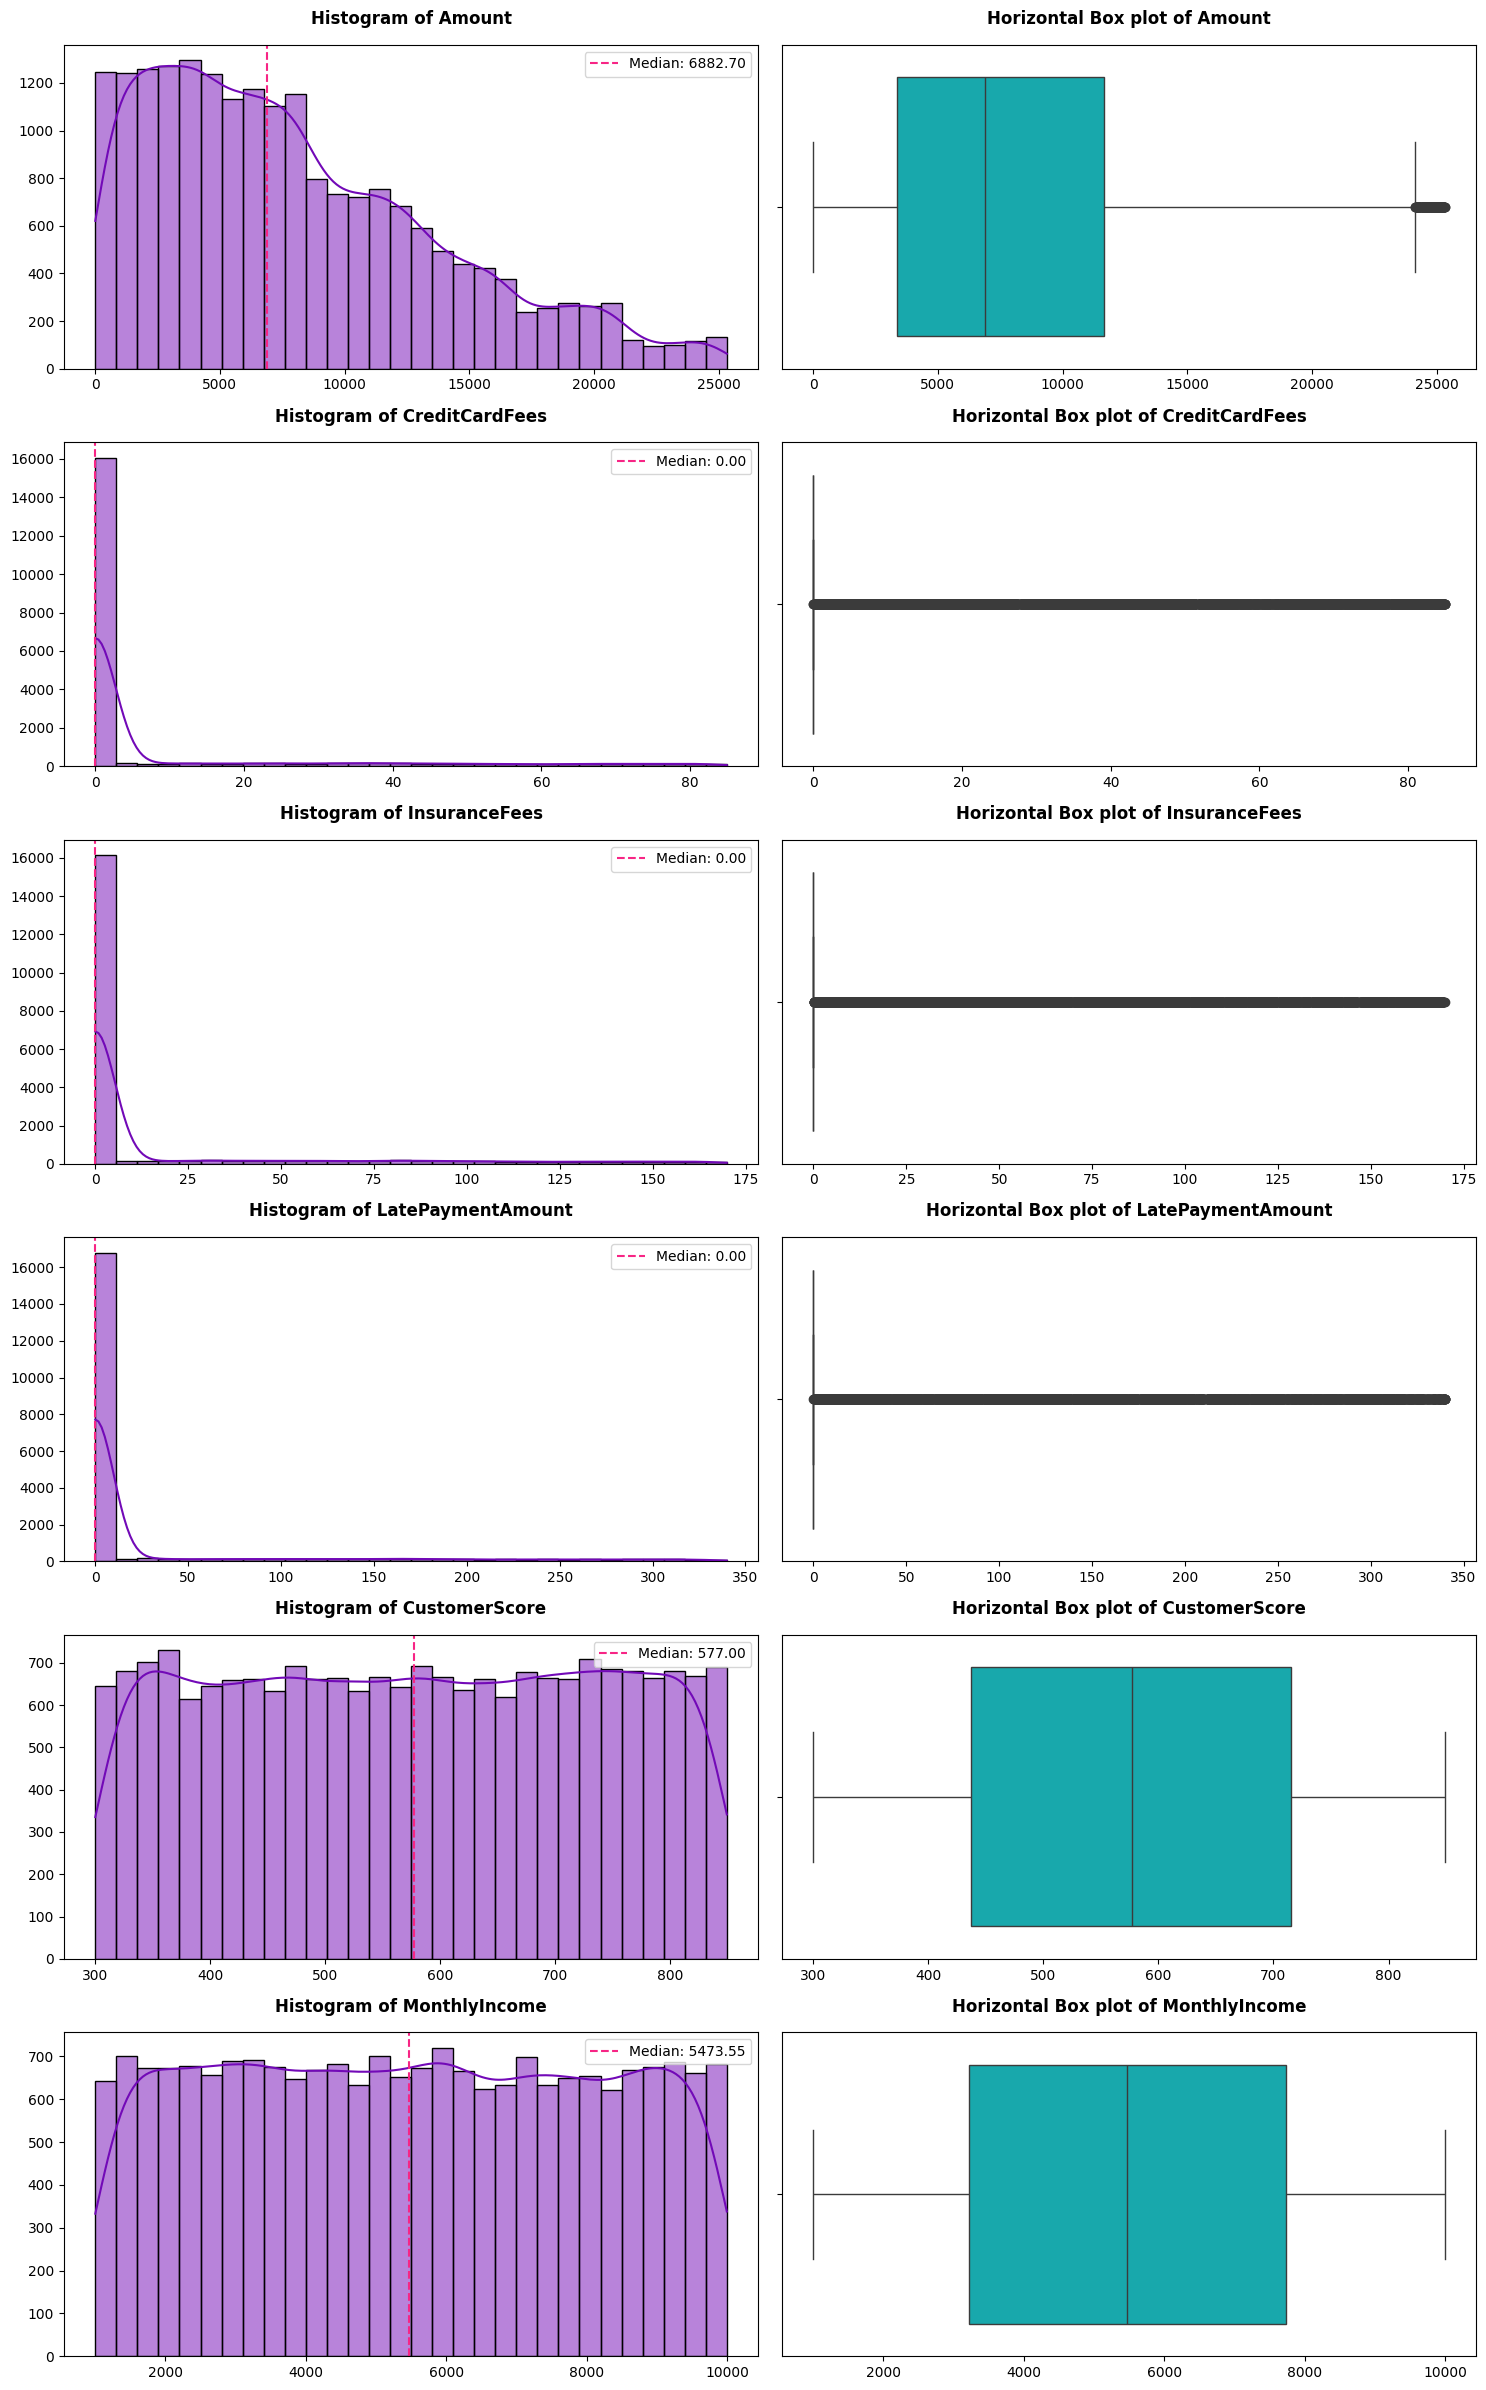

In [147]:
def plot_numerical_features(df=df_bank_transactions, numerical_features = num_features):
    """
    Plot histogram and boxplot for each numerical feature.

    - Histogram shows distribution and skewness.
    - Boxplot highlights median and potential outliers.
    """
    # Create subplot grid: one row per feature, 2 columns (histogram + boxplot)
    fig, ax = plt.subplots(len(numerical_features), 2, figsize=(15, len(numerical_features)*4))
    # Ensure ax is always 2D for consistent indexing
    ax = np.atleast_2d(ax)

    for i, feature in enumerate(numerical_features):
        # Histogram with KDE
        sns.histplot(data=df[feature], color="#7209b7", bins = 30, kde=True, ax=ax[i, 0])
        ax[i, 0].set_title(f"Histogram of {feature}", fontsize=12, pad=15, weight="bold")
        ax[i, 0].set_xlabel("")
        ax[i, 0].set_ylabel("")
        # Median reference line
        ax[i, 0].axvline(df[feature].median(), color="#f72585", linestyle="--", label=f"Median: {df[feature].median():.2f}")
        ax[i, 0].legend()

        # Horizontal boxplot for outlier visualization
        sns.boxplot(data=df[feature], color="#00BFC4", orient="h", ax=ax[i, 1])
        ax[i, 1].set_title(f"Horizontal Box plot of {feature}", fontsize=12, pad=15, weight="bold")
        ax[i, 1].set_xlabel("")

     # Adjust layout to prevent overlapping
    plt.tight_layout()
    plt.show()

# Run visualization for numerical features
plot_numerical_features()

In [148]:
def check_skewness(data, dataset_name, numerical_features=num_features, sort=True, logger=logger):
    """
    Analyze skewness of numerical features in a dataset and log summary insights.

    This function computes the skewness for each numerical feature, optionally
    sorts them by absolute skewness, and categorizes features based on the
    degree of skewness. Detailed results are logged at DEBUG level, while
    high-level insights and recommendations are logged at INFO level.

    Parameters
    ----------
    data : pandas.DataFrame
        The input dataset containing numerical features to be analyzed.

    dataset_name : str
        A descriptive name of the dataset, used for logging and reporting.

    numerical_features : list of str, optional
        List of numerical feature names to evaluate.
        Default is `num_features`.

    sort : bool, optional (default=True)
        If True, sort features by absolute skewness in descending order.

    logger : logging.Logger
        Logger object used to output analysis results and insights.

    Returns
    -------
    list of str
        A list of feature names that are considered highly skewed
        (|skewness| > 1).

    Notes
    -----
    - Skewness interpretation:
        * |skew| ≤ 0.5  : Approximately symmetric
        * 0.5 < |skew| ≤ 1 : Moderately skewed
        * |skew| > 1   : Highly skewed
    - Highly skewed features may benefit from transformations such as:
        log, Box-Cox, or Yeo-Johnson.
    - This function is intended for exploratory data analysis (EDA)
      and feature preprocessing stages.
    """

    skewness_dict = {}
    skew_features = []
    for feature in numerical_features:
        skew = data[feature].skew(skipna=True)
        skewness_dict[feature] = skew

    skew_df = pd.DataFrame.from_dict(skewness_dict, orient="index", columns=["Skewness"])
    if sort:
        skew_df = skew_df.reindex(skew_df["Skewness"].abs().sort_values(ascending=False).index)

    # ===== Summary header =====
    logger.info(f"Skewness analysis for {dataset_name}")
    logger.info(f"Total numerical features checked: {len(skew_df)}")

    # ===== Detailed table (DEBUG) =====
    logger.debug("-"*80)
    logger.debug(f"{'Feature':<30} | {'Skewness':<9} | {'Remark'}")
    logger.debug("-"*80)
    for feature, row in skew_df.iterrows():
        skew = row["Skewness"]
        abs_skew = abs(skew)
        if abs_skew > 1:
            remark = "Highly skewed"
            skew_features.append(feature)
        elif abs_skew > 0.5:
            remark = "Moderately skewed"
            skew_features.append(feature)
        else:
            remark = "Approximately symmetric"
        logger.debug(f"{feature:<30} | {skew:>+9.4f} | {remark}")
    logger.debug("-" * 80)

    # ===== Summary insight =====
    if skew_features:
        logger.info(f"{len(skew_features)} features are highly skewed (|skew| > 1).")
        logger.info(f"Recommendation: Consider log / Box-Cox / Yeo-Johnson transformation.")
    else:
        logger.info("No highly skewed features detected.")

    return skew_features

skew_feature = check_skewness(df_bank_transactions, "Data Banking")
logger.info("-" * 80)
logger.info("Checking skewness successfully completed the dataset.")

2026-04-14 20:25:20 | INFO     | Skewness analysis for Data Banking
2026-04-14 20:25:20 | INFO     | Total numerical features checked: 6
2026-04-14 20:25:20 | DEBUG    | --------------------------------------------------------------------------------
2026-04-14 20:25:20 | DEBUG    | Feature                        | Skewness  | Remark
2026-04-14 20:25:20 | DEBUG    | --------------------------------------------------------------------------------
2026-04-14 20:25:20 | DEBUG    | LatePaymentAmount              |   +2.7974 | Highly skewed
2026-04-14 20:25:20 | DEBUG    | InsuranceFees                  |   +2.4779 | Highly skewed
2026-04-14 20:25:20 | DEBUG    | CreditCardFees                 |   +2.4119 | Highly skewed
2026-04-14 20:25:20 | DEBUG    | Amount                         |   +0.7889 | Moderately skewed
2026-04-14 20:25:20 | DEBUG    | MonthlyIncome                  |   +0.0149 | Approximately symmetric
2026-04-14 20:25:20 | DEBUG    | CustomerScore                  |   -0.0086 

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Skewness Analysis Insights
</div>

<h3 style="margin-top:10px;">Feature Distribution Analysis</h3>
<ul style="line-height: 1.8; padding-left: 20px;">

<li><b>TransactionAmount</b>: Highly right-skewed (+1.77) → most transactions are small, with a few significantly large values → strong signal for <b>potential high-value anomalies</b>.</li>

<li><b>TransactionDuration</b>: Moderately right-skewed (+0.62) → majority of transactions are short, but some take longer than usual → may indicate <b>unusual transaction behavior</b>.</li>

<li><b>AccountBalance</b>: Moderately right-skewed (+0.60) → most customers have mid-range balances, while a small portion holds very high balances → useful for <b>customer segmentation and financial profiling</b>.</li>

<li><b>CustomerAge</b>: Approximately symmetric (+0.15) → evenly distributed across age groups → unlikely to introduce bias in modeling.</li>

</ul>

<h3>Interpretation</h3>
<ul style="line-height: 1.8; padding-left: 20px;">

<li>Majority of financial and behavioral features exhibit <b>right-skewed distributions</b>.</li>

<li>This indicates the presence of <b>rare but impactful events</b> (e.g., large transactions or long durations), which are critical for anomaly detection.</li>

<li>Highly skewed features (especially <code>TransactionAmount</code>) may affect model performance if left untransformed.</li>

</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Conclusion:</b> The dataset shows <b>right-skewed behavior in key numerical features</b>, reflecting realistic financial patterns where extreme values are rare but important.  
Applying transformations (e.g., <b>log, Box-Cox, or Yeo-Johnson</b>) can help <b>normalize distributions</b> and improve model stability, especially for anomaly detection tasks.
</div>

</div>

## Categorical Feature Distributions

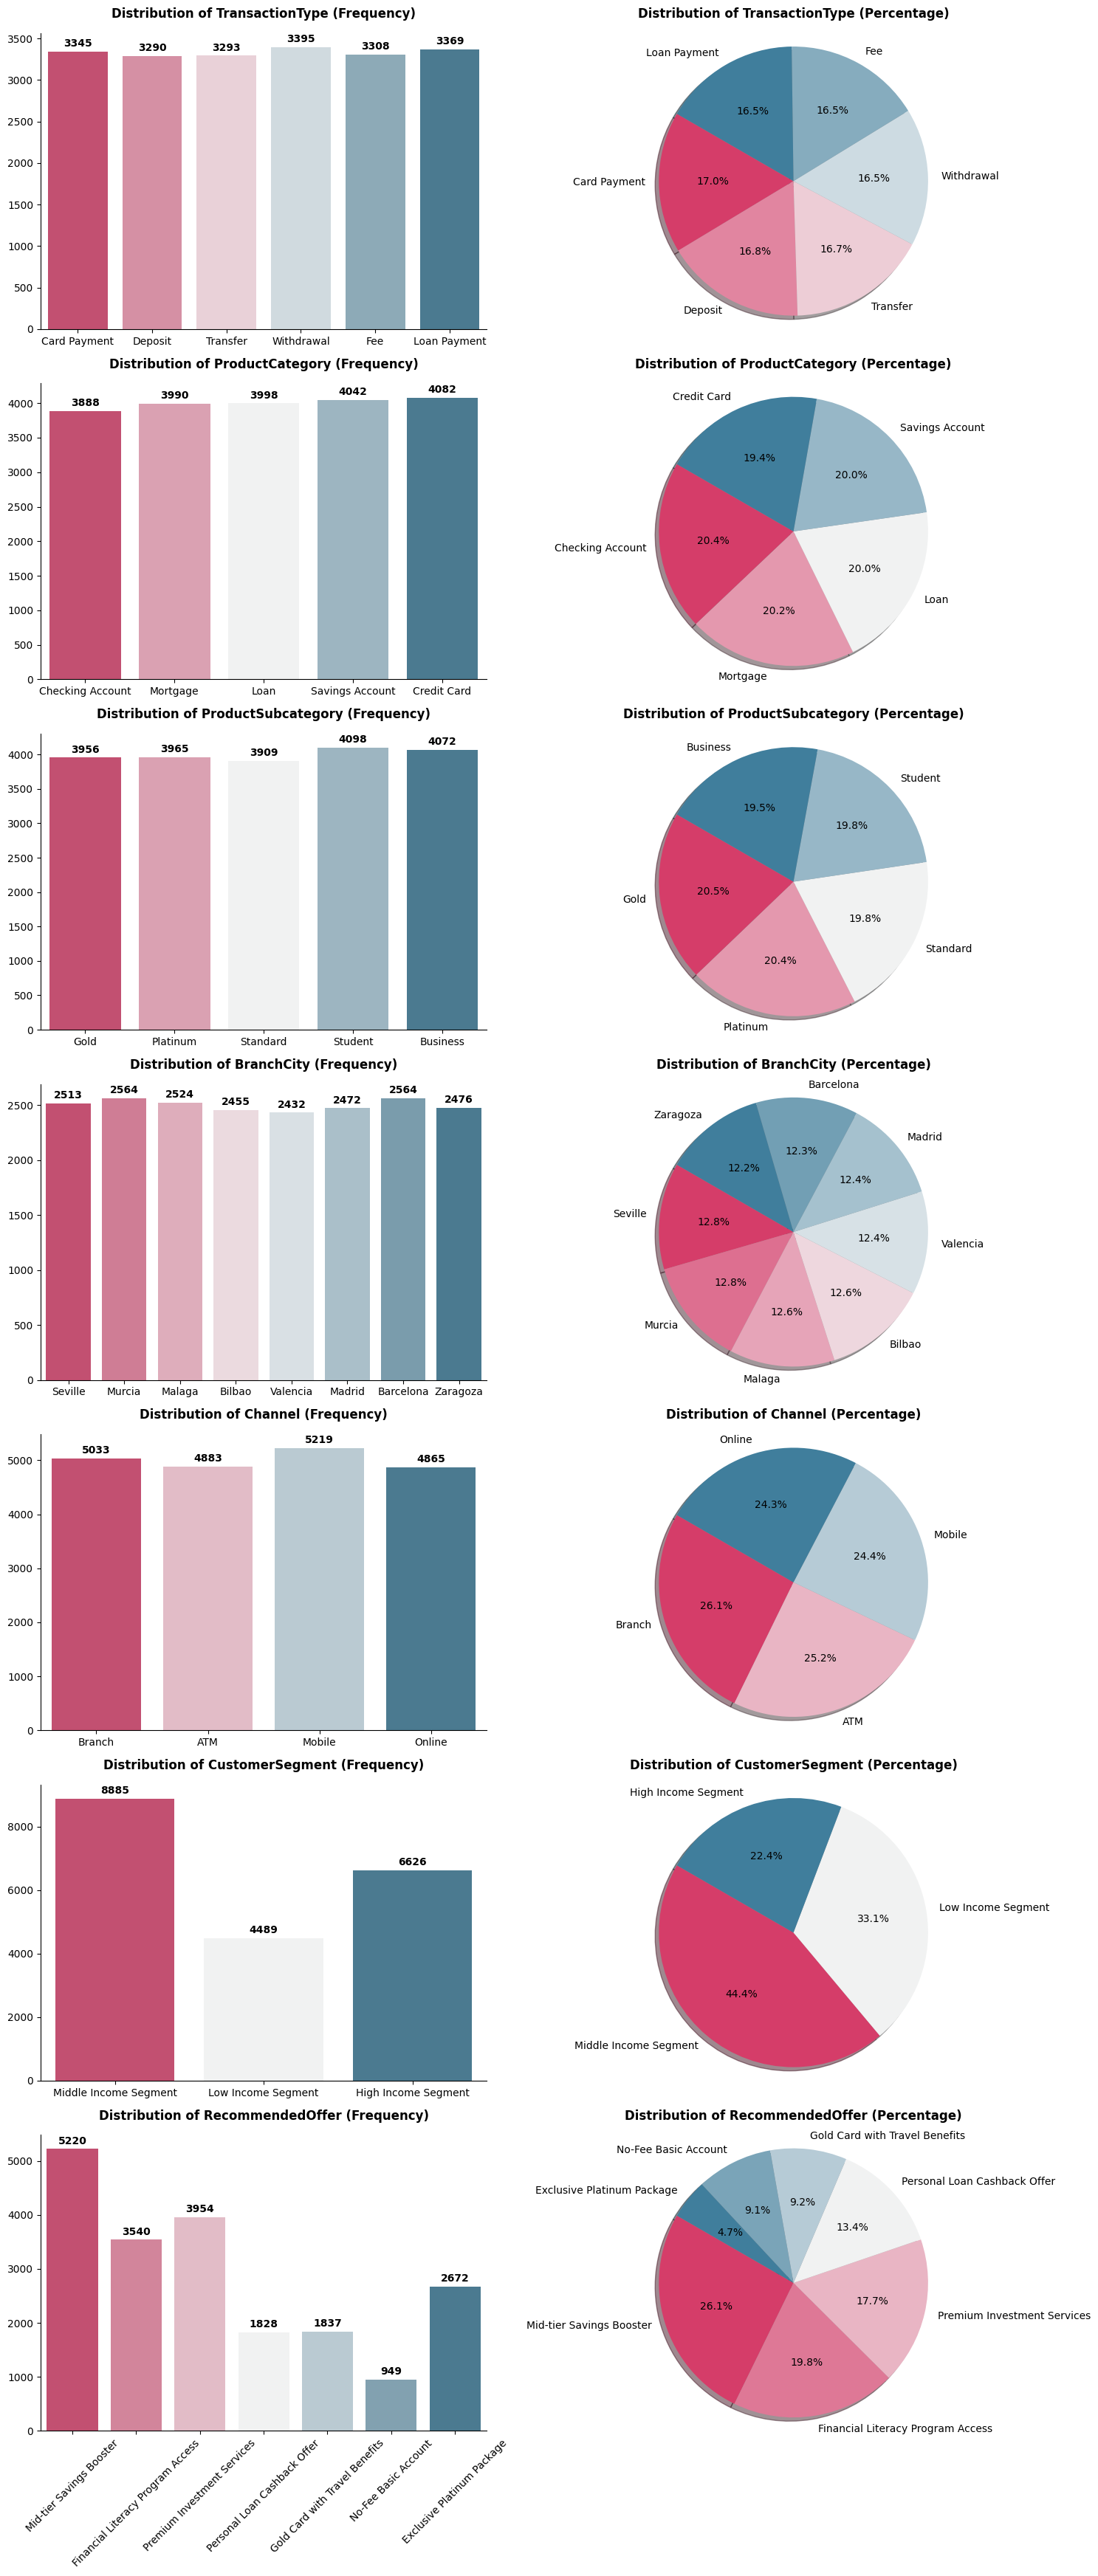

In [149]:
def plot_categorical_distribution(df: pd.DataFrame, cat_features: str) -> None:
    """
    Plot count and percentage distribution for categorical features.

    - Left: countplot with value labels.
    - Right: pie chart showing percentage distribution.
    """
    # Create subplot grid: one row per feature, 2 columns (countplot + pie)
    fig, ax = plt.subplots(len(cat_features), 2, figsize=(15, len(cat_features) * 5))
    ax = np.atleast_2d(ax)

    for i, feature in enumerate(cat_features):
        # Preserve original category order
        order_feature = df[feature].unique().tolist()

        # LEFT: Countplot for frequency distribution
        sns.countplot(data=df, x=feature, ax=ax[i, 0], palette=color(n_colors=len(df[feature].unique())), 
                      order=order_feature)
        ax[i, 0].set_title(f"Distribution of {feature} (Frequency)", fontsize=12, pad=15, weight="bold")
        ax[i, 0].set_xlabel("")
        ax[i, 0].set_ylabel("")
        # Rotate x-axis labels
        if feature == "RecommendedOffer":
            ax[i, 0].tick_params(axis="x", rotation=45)
        sns.despine(ax=ax[i, 0], top=True, right=True)

        # Add count labels on bars
        for p in ax[i, 0].patches:
            height = p.get_height()
            x = p.get_x() + p.get_width() / 2
            ax[i, 0].text(x, height + max(df[feature].value_counts()) * 0.01,
                          f"{int(height)}", ha="center", va="bottom",
                          fontsize=10, fontweight="bold")

        # RIGHT: Pie chart for percentage distribution
        feature_counts = df[feature].value_counts(normalize=True)
        sizes = feature_counts.values * 100  # percentage
        colors = color(n_colors=len(df[feature].unique()))

        wedges, texts, autotexts = ax[i, 1].pie(
            sizes, labels=order_feature, autopct="%1.1f%%", shadow= True,
            startangle=150, colors=colors, textprops={"fontsize": 10}
        )
        ax[i, 1].set_title(f"Distribution of {feature} (Percentage)", fontsize=12, pad=15, weight="bold")
        ax[i, 1].axis("equal")

    # Adjust layout to avoid overlapping
    plt.tight_layout()
    plt.show()

# Run categorical distribution plots
plot_categorical_distribution(df=df_bank_transactions, cat_features=cat_features)

## RFM Analysis

In [150]:
# Define the reference date = the latest transaction date + 1 day
# +1 day is added to avoid Recency = 0 for customers who transacted on the last day
recency_date = df_bank_transactions["TransactionDate"].max() + pd.Timedelta(days=1)

# Calculate RFM for each customer (CustomerID)
df_rfm = df_bank_transactions.groupby("CustomerID").agg({
    # Recency = (reference date - most recent transaction date of the customer)
    "TransactionDate": lambda x: (recency_date - x.max()).days,
    
    # Frequency = number of transactions (count unique TransactionID)
    "TransactionID": "nunique",
    
    # Monetary = total transaction amount
    "Amount": "sum"
}).reset_index()

# Rename columns for better readability
df_rfm.columns = ["CustomerID", "recency", "frequency", "monetary"]

display(df_rfm.head())

,CustomerID,recency,frequency,monetary
0,1000,359,1,15808.987936
1,1001,80,5,26470.355529
2,1002,641,2,23953.802954
3,1003,2,1,8858.728720
4,1004,186,3,39273.474309


In [151]:
# R score: lower recency (more recent purchase) → higher score
P20 = df_rfm["recency"].quantile(0.2)
P40 = df_rfm["recency"].quantile(0.4)
P60 = df_rfm["recency"].quantile(0.6)
P80 = df_rfm["recency"].quantile(0.8)

conditions = [
    df_rfm["recency"] <= P20,
    df_rfm["recency"] <= P40,
    df_rfm["recency"] <= P60,
    df_rfm["recency"] <= P80
]
choices = [5, 4, 3, 2]

df_rfm["r_score"] = np.select(conditions, choices, default=1)

# F score: higher purchase frequency → higher score
P20 = df_rfm["frequency"].quantile(0.2)
P40 = df_rfm["frequency"].quantile(0.4)
P60 = df_rfm["frequency"].quantile(0.6)
P80 = df_rfm["frequency"].quantile(0.8)

conditions = [
    df_rfm["frequency"] >= P80,
    df_rfm["frequency"] >= P60,
    df_rfm["frequency"] >= P40,
    df_rfm["frequency"] >= P20
]
choices = [5, 4, 3, 2]

df_rfm["f_score"] = np.select(conditions, choices, default=1)

# M score: higher monetary value → higher score
P20 = df_rfm["monetary"].quantile(0.2)
P40 = df_rfm["monetary"].quantile(0.4)
P60 = df_rfm["monetary"].quantile(0.6)
P80 = df_rfm["monetary"].quantile(0.8)

conditions = [
    df_rfm["monetary"] >= P80,
    df_rfm["monetary"] >= P60,
    df_rfm["monetary"] >= P40,
    df_rfm["monetary"] >= P20
]
choices = [5, 4, 3, 2]

df_rfm["m_score"] = np.select(conditions, choices, default=1)

# Combine R, F, M scores into a 3-digit RFM score
df_rfm["rfm_score"] = (
    df_rfm["r_score"].astype(str)
    + df_rfm["f_score"].astype(str)
    + df_rfm["m_score"].astype(str)
)

# Map RFM score to business-defined customer segments
df_rfm["rfm_segment"] = df_rfm["rfm_score"].apply(CFG.rfm_segment)
display(df_rfm.head())

,CustomerID,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_segment
0,1000,359,1,15808.987936,2,2,3,223,Hibernating Customers
1,1001,80,5,26470.355529,4,5,4,454,Champions
2,1002,641,2,23953.802954,1,3,4,134,At Risk
3,1003,2,1,8858.728720,5,2,2,522,Promising
4,1004,186,3,39273.474309,3,4,5,345,Loyal


In [152]:
# 1. Merge transaction data with RFM segmentation
#    - Join df (transaction-level) with df_rfm (customer-level RFM segment)
df_merged = df_bank_transactions.merge(
    df_rfm[["CustomerID", "rfm_segment"]],
    on="CustomerID",
    how="inner"
)

# 2. Create RFM summary DataFrame
summary_rfm_df = (
    df_merged
    .groupby("rfm_segment", as_index=False)
    .agg(
        customer_count=("CustomerID", "nunique"),                                   # Number of unique customers per segment
        total_amount=("Amount", "sum"),                                             # Total amount
        total_transaction =("TransactionID", "nunique")                             # Total transaction
    )
    .sort_values("total_amount", ascending=False)                                   # Show largest segments first
    .reset_index(drop=True)
)

# 3. Create styled table for presentation (PRESENTATION LAYER)
#    - Styling is applied ONLY for display
#    - Does not affect the underlying DataFrame
summary_rfm_style = (
    summary_rfm_df
    .style
    .set_caption("RFM Summary by Segment")
    
    # Format numeric columns
    .format({"total_amount": "{:,.2f}",
             "total_transaction": "{:,.0f}"
             })
    
    # Style table header and caption
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "caption", "props": [
            ("caption-side", "top"),
            ("font-size", "16px"),
            ("font-weight", "bold")
        ]}
    ])
    
    # Apply general cell properties
    .set_properties(**{
        "text-align": "center",
        "font-size": "12px"
    })
    
    # Apply color gradient to highlight magnitude differences
    .background_gradient(
        subset=["customer_count", "total_amount", "total_transaction"],
        cmap="Greens"
    )
)

# 4. Display styled RFM summary table
display(summary_rfm_style)

,rfm_segment,customer_count,total_amount,total_transaction
0,Champions,1296,"49,515,379.83","5,540"
1,At Risk,1134,"30,302,662.43","3,230"
2,Loyal,805,"25,566,517.51","2,798"
3,Potential Loyalist,1270,"16,919,929.73","3,082"
4,Hibernating Customers,1295,"16,158,318.26","1,912"
5,Need Attention,536,"12,020,087.73","1,269"
6,Cannot Lose Them,88,"2,782,334.59",317
7,About To Sleep,613,"2,548,351.94",791
8,Lost Customers,567,"2,068,169.41",640
9,Promising,201,"1,731,808.03",201


2026-04-14 20:25:23 | INFO     | Pareto Analysis of Total Amount by RFM Segment


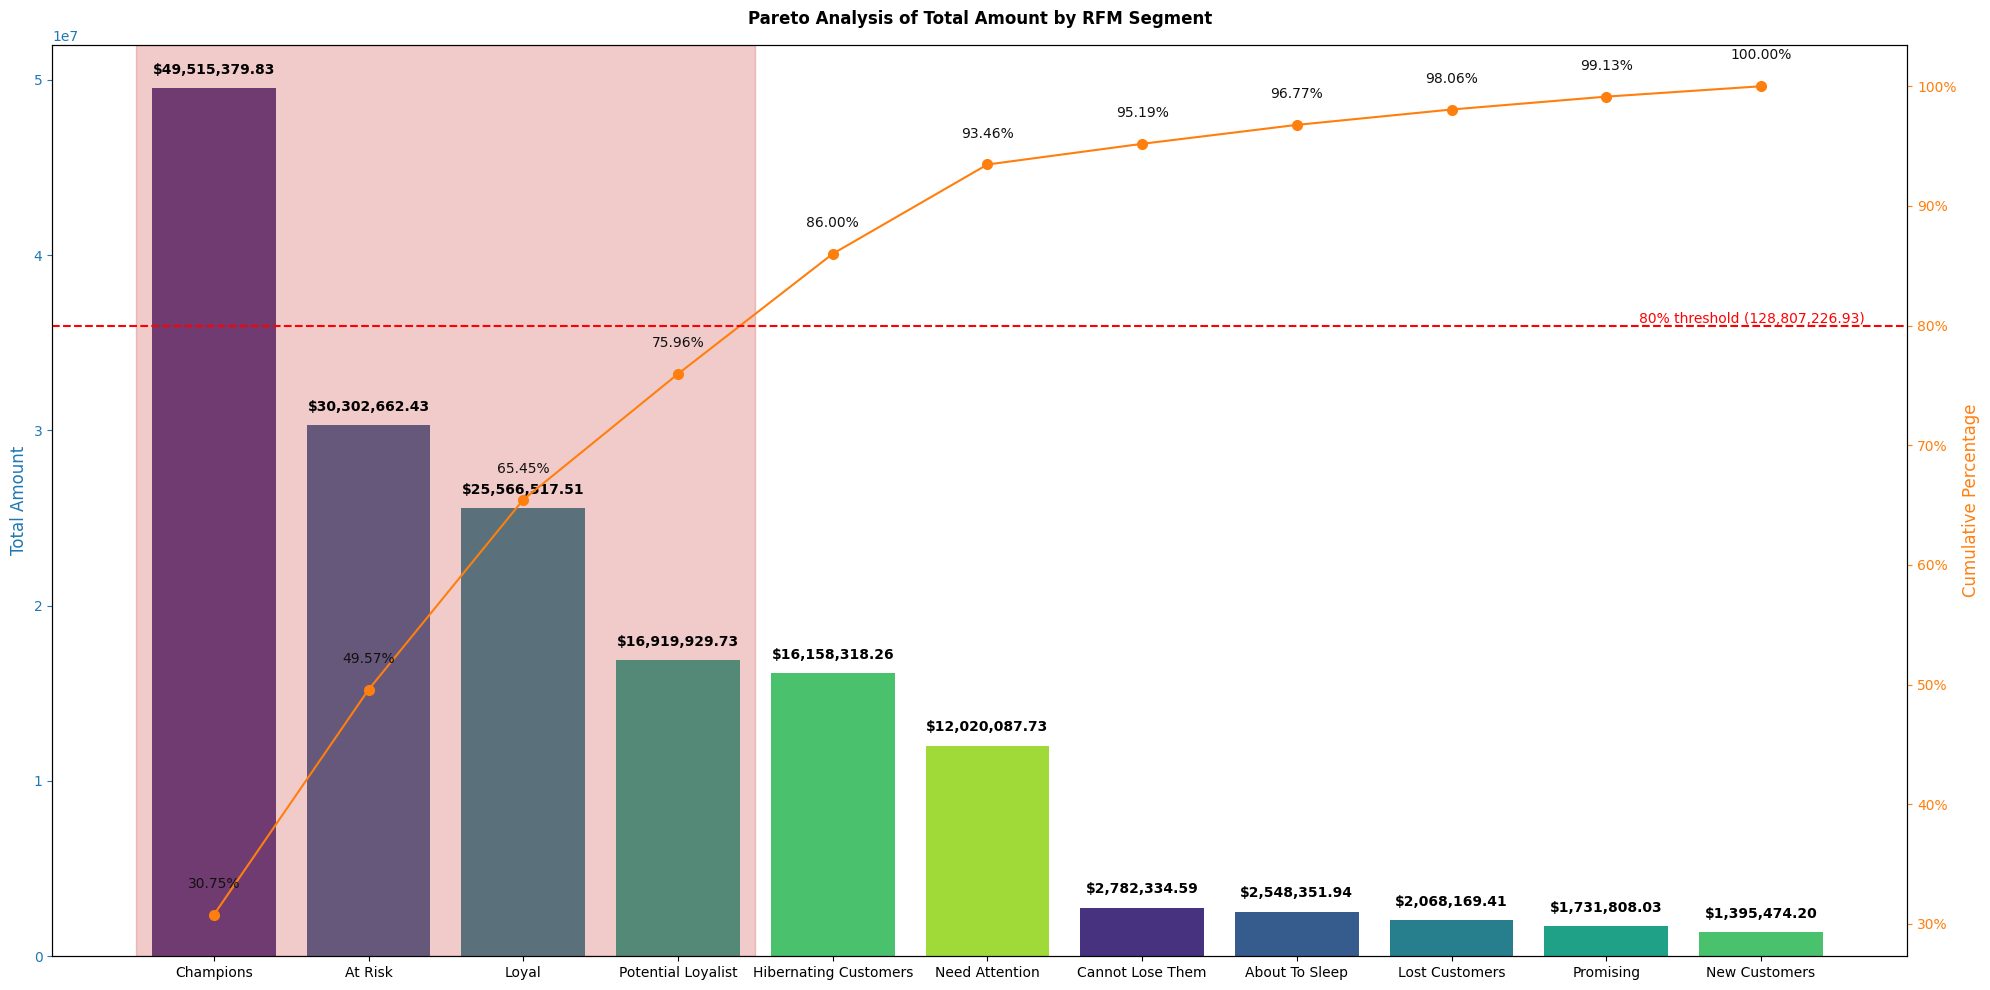

2026-04-14 20:25:23 | INFO     | Pareto Analysis of Total Transaction by RFM Segment


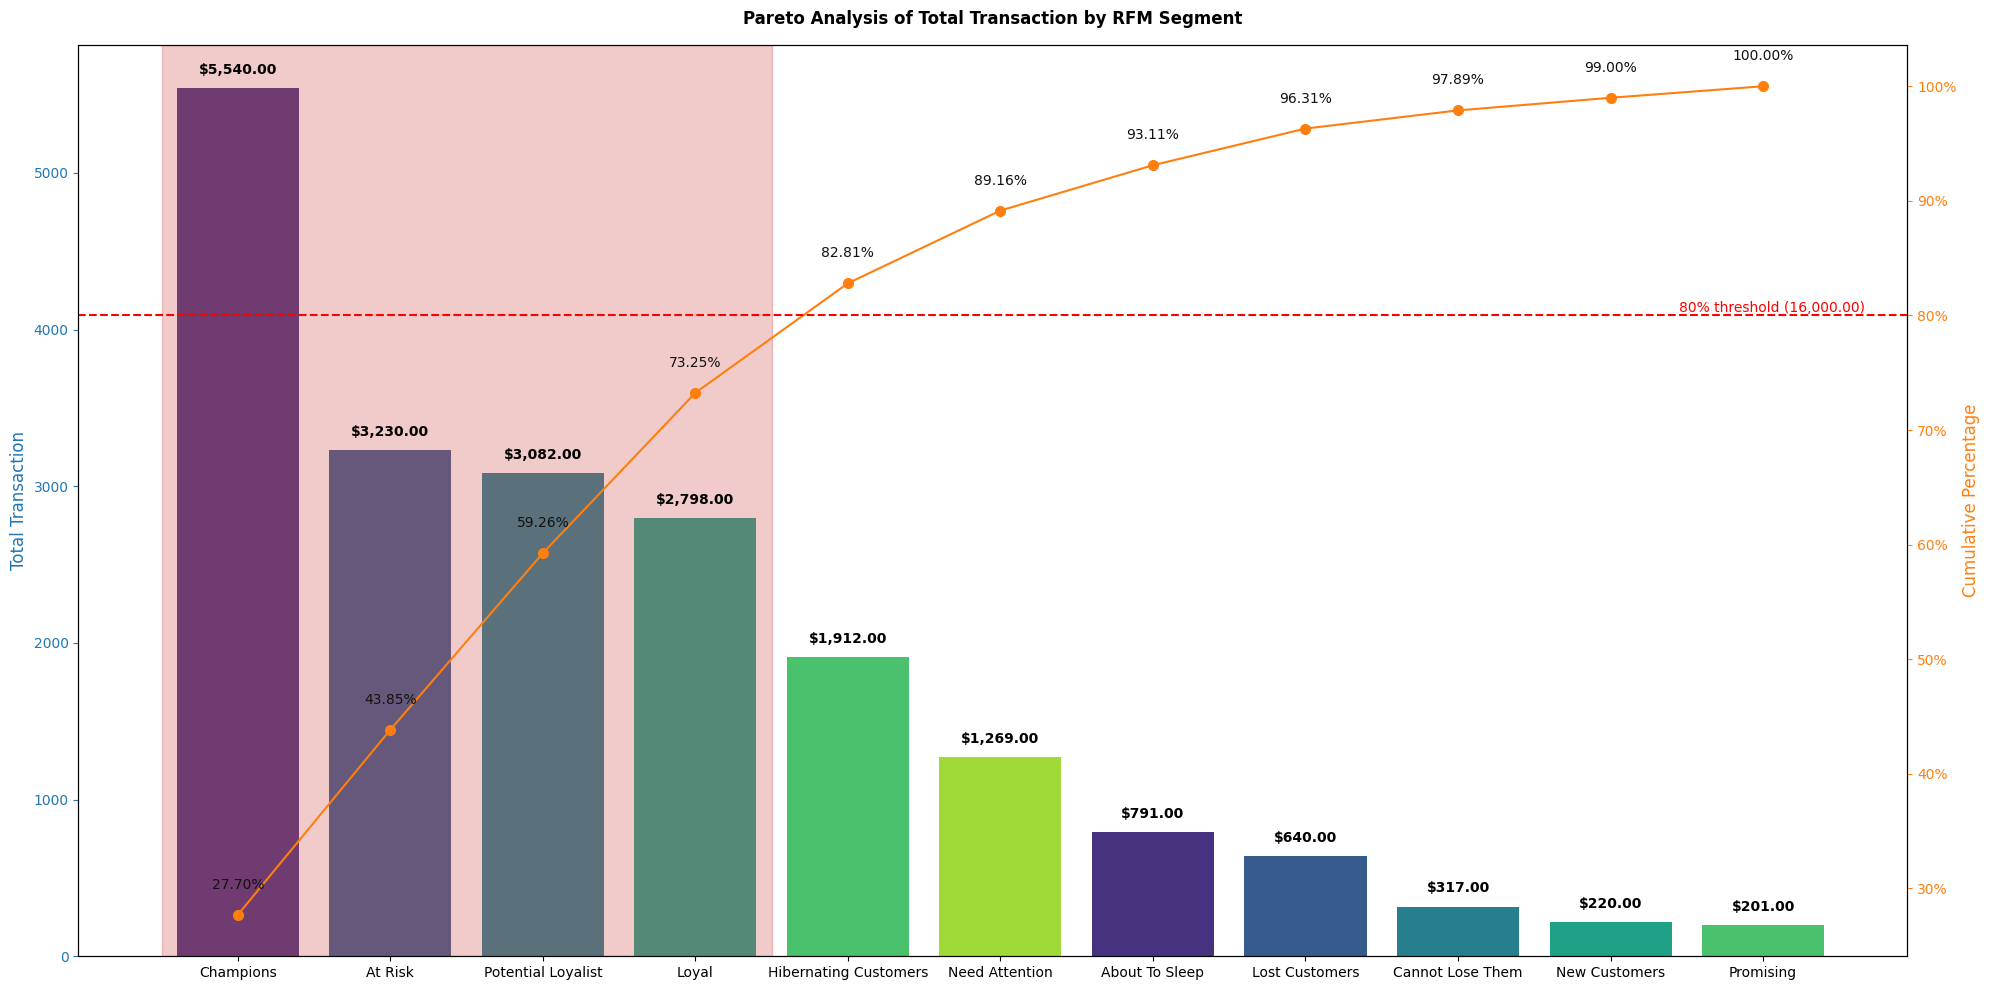

In [153]:
def pareto_analysis(feature:str="total_amount", summary_rfm_df: pd.DataFrame=summary_rfm_df) -> None:
    """Plot Pareto chart to identify top 80% contributing RFM segments."""

    # Sort segments by selected metric (descending)
    summary_rfm_pareto = summary_rfm_df.sort_values(
        by=feature, ascending=False
    ).reset_index(drop=True)

    # Calculate cumulative percentage
    summary_rfm_pareto["cumpercentage"] = (
        summary_rfm_pareto[feature].cumsum()
        / summary_rfm_pareto[feature].sum() * 100
    )

    # Flag segments contributing to top 80%
    summary_rfm_pareto["Top80"] = summary_rfm_pareto["cumpercentage"] <= 80

    # Initialize Pareto chart
    fig, ax = plt.subplots(figsize=(20, 10))

    palette = color(n_colors=summary_rfm_pareto["rfm_segment"].nunique(), tone="viridis")
    bars = ax.bar(
        summary_rfm_pareto["rfm_segment"],
        summary_rfm_pareto[feature],
        color=palette
    )

    # Highlight background area for top 80%
    cutoff_index = summary_rfm_pareto[summary_rfm_pareto["Top80"]].index.max()
    ax.axvspan(-0.5, cutoff_index + 0.5, color="#d35252", alpha=0.3)

    # Add value labels on bars
    ax.bar_label(
        bars,
        labels=[f"${v:,.2f}" for v in summary_rfm_pareto[feature]],
        padding=8,
        fontsize=10,
        color="black",
        weight="bold"
    )

    # Plot cumulative percentage line
    ax1 = ax.twinx()
    ax1.plot(
        summary_rfm_pareto["rfm_segment"],
        summary_rfm_pareto["cumpercentage"],
        color="#ff7f0e",
        marker="o",
        ms=7
    )
    ax1.yaxis.set_major_formatter(PercentFormatter())

    for x, y in zip(summary_rfm_pareto["rfm_segment"], summary_rfm_pareto["cumpercentage"]):
        ax1.text(x, y + 2, f"{y:.2f}%", color="#111110", fontsize=10, ha="center", va="bottom")

    # Draw 80% threshold line and label
    total_m_sum = summary_rfm_pareto[feature].sum()
    threshold_80_value = total_m_sum * 0.8
    ax1.axhline(80, color="red", linestyle="--", linewidth=1.5)
    ax1.text(
        len(summary_rfm_pareto) * 0.97,
        80,
        f"80% threshold ({threshold_80_value:,.2f})",
        color="red",
        fontsize=10,
        ha="right",
        va="bottom"
    )

    # Axis styling and labels
    ax.set_ylabel(feature.replace("_", " ").title(), color="C0", fontsize=12)
    ax1.set_ylabel("Cumulative Percentage", color="#ff7f0e", fontsize=12)
    ax.tick_params(axis="y", colors="C0")
    ax1.tick_params(axis="y", colors="#ff7f0e")
    # plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.title(f"Pareto Analysis of {feature.replace('_', ' ').title()} by RFM Segment", fontsize=12, pad=15, weight="bold")

    fig.tight_layout()
    plt.show()

for feature in ["total_amount", "total_transaction"]:
    logger.info(f"Pareto Analysis of {feature.replace('_', ' ').title()} by RFM Segment")
    pareto_analysis(feature=feature)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 RFM Pareto Insights
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li><b>Champions</b>: Contributes the most (~30% of total amount, ~28% of transactions) → represents the <b>highest-value customers</b>, requiring top retention priority.</li>

<li><b>Pareto Effect</b>: The top ~4 segments (<code>Champions + At Risk + Loyal + Potential Loyalist</code>) contribute ~75–80% of total value → clearly reflects the <b>80/20 rule</b>.</li>

<li><b>At Risk</b>: Ranks second in contribution → consists of <b>high-value customers with churn risk</b>, requiring immediate retention actions.</li>

<li><b>Loyal & Potential Loyalist</b>: Show stable contributions → ideal segments for <b>upselling and cross-selling strategies</b>.</li>

<li><b>Low-Contribution Segments</b>: Groups such as <code>Need Attention</code>, <code>Lost</code>, <code>New</code>, and <code>Promising</code> contribute relatively little (&lt;20%) → marketing efforts should be <b>optimized and selectively prioritized</b>.</li>

</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Conclusion:</b> Revenue is highly concentrated in a few key segments.  
An effective strategy should focus on <b>retaining Champions</b>, <b>re-engaging At Risk customers</b>, and <b>maximizing value from Loyal segments</b>.
</div>

</div>

## Cohort Analysis

### Customer Retention

In [154]:
df_bank_transactions_cohort = df_bank_transactions.copy()

from operator import attrgetter

# TransactionDate
df_bank_transactions_cohort["cohort"] = df_bank_transactions_cohort.groupby("CustomerID")["TransactionDate"].transform("min").dt.to_period("M")
df_bank_transactions_cohort["order_month"] = df_bank_transactions_cohort["TransactionDate"].dt.to_period("M")
# Create cohort dataframe
df_cohort = df_bank_transactions_cohort.groupby(["cohort", "order_month"]).agg(n_customers=("CustomerID", "nunique")).reset_index(drop=False)

# period_number
df_cohort["period_number"] = (df_cohort.order_month - df_cohort.cohort).apply(attrgetter("n"))
display(df_cohort.head())

,cohort,order_month,n_customers,period_number
0,2023-01,2023-01,711,0
1,2023-01,2023-02,48,1
2,2023-01,2023-03,53,2
3,2023-01,2023-04,51,3
4,2023-01,2023-05,53,4


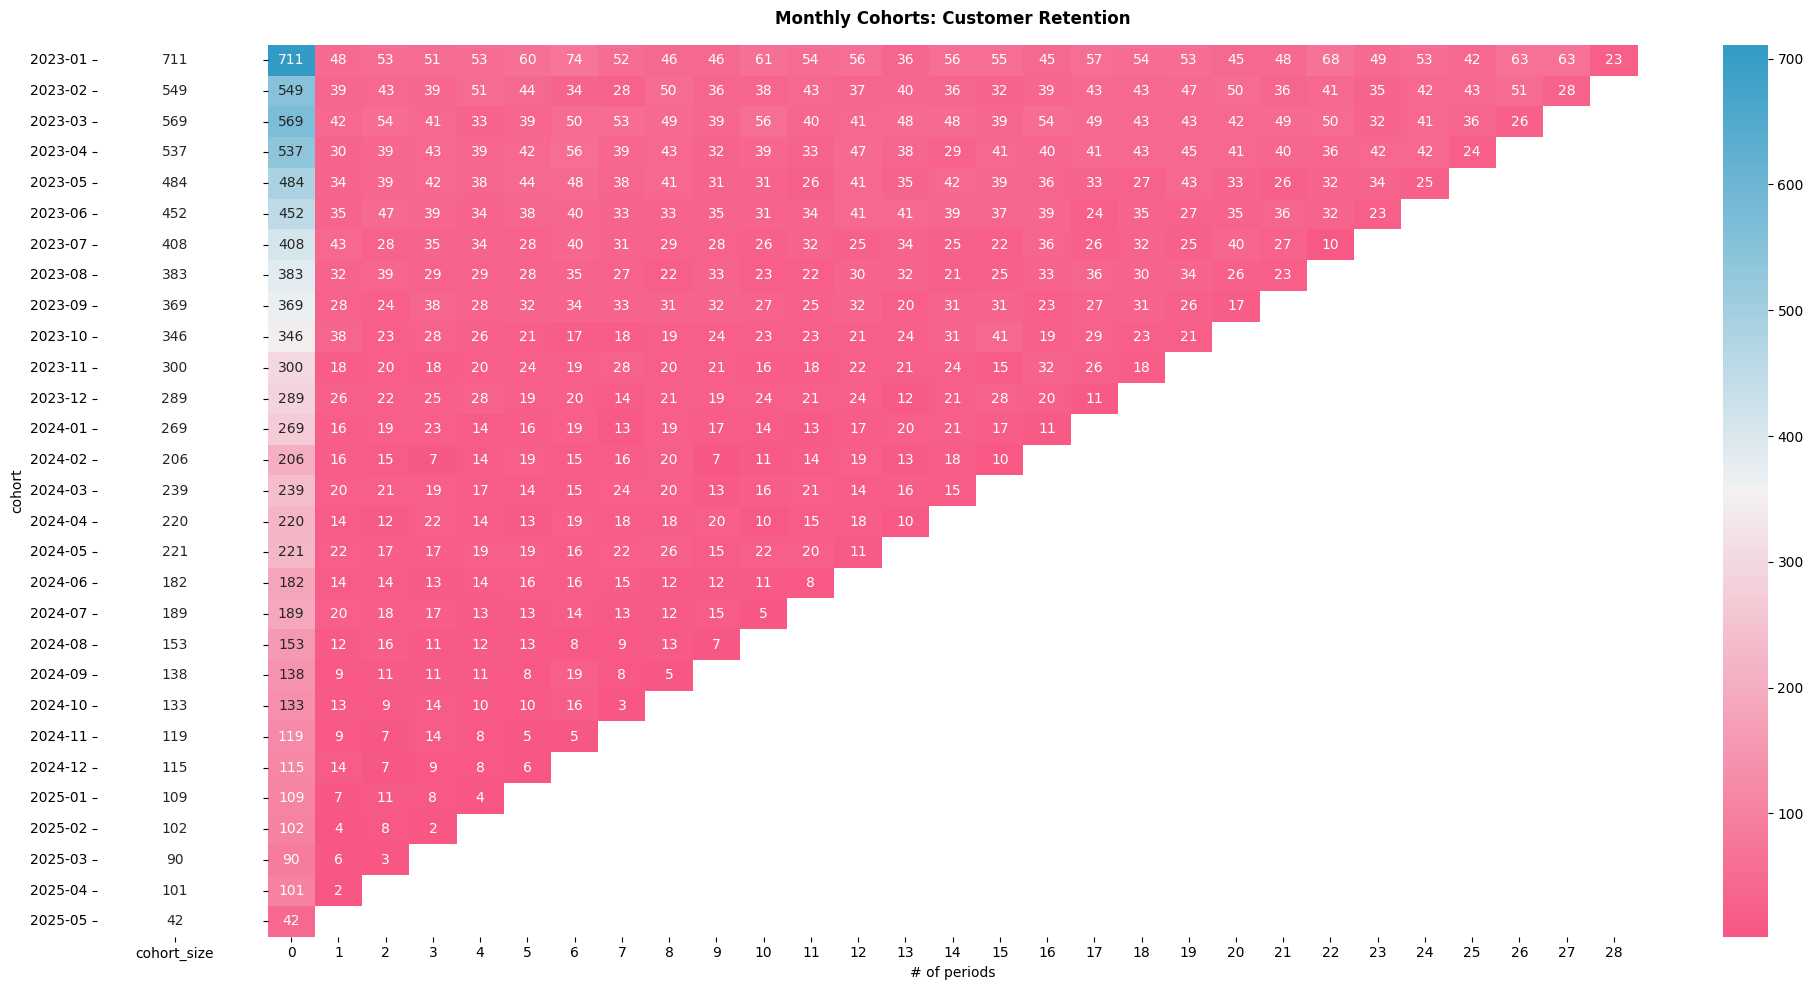

In [155]:
cohort_pivot = df_cohort.pivot_table(index="cohort", columns="period_number", values="n_customers")
cohort_size = cohort_pivot.iloc[:, 0]
fig, ax = plt.subplots(1, 2, figsize=(20, 10), sharey=True, gridspec_kw={"width_ratios": [1, 11]})
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
# retention matrix
sns.heatmap(cohort_pivot, mask=cohort_pivot.isnull(), annot=True, fmt=".0f", cmap=cmap, ax=ax[1])
ax[1].set_title("Monthly Cohorts: Customer Retention", fontsize=12, pad=15, weight="bold")
ax[1].set(xlabel="# of periods", ylabel="")

# cohort size
cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: "cohort_size"})
white_cmap = mcolors.ListedColormap(["white"])
sns.heatmap(cohort_size_df, annot=True, cbar=False, fmt="g", cmap=white_cmap, ax=ax[0])

plt.tight_layout()
plt.show()

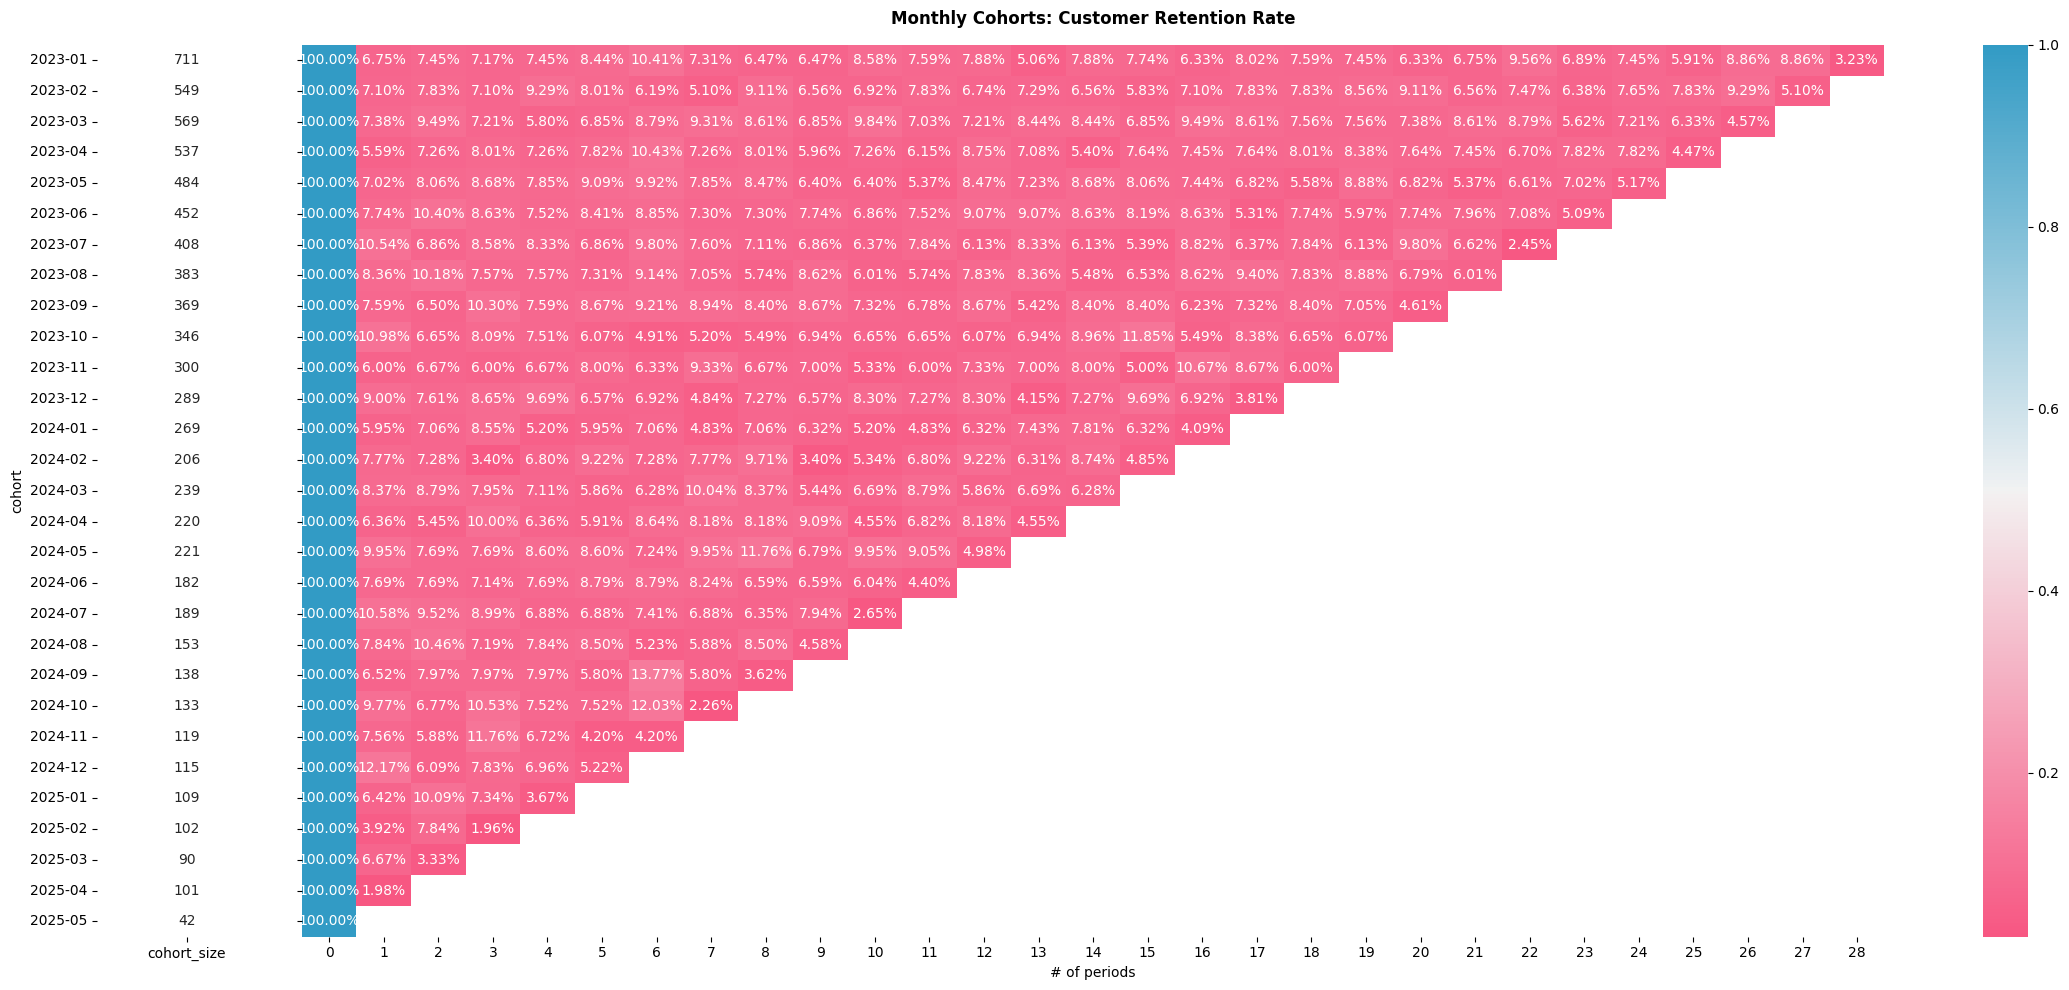

In [156]:
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)
fig, ax = plt.subplots(1, 2, figsize=(23, 10), sharey=True, gridspec_kw={"width_ratios": [1, 11]})
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
# retention matrix
sns.heatmap(retention_matrix, mask=retention_matrix.isnull(), annot=True, fmt=".2%", cmap=cmap, ax=ax[1])
ax[1].set_title("Monthly Cohorts: Customer Retention Rate", fontsize=12, pad=15, weight="bold")
ax[1].set(xlabel="# of periods", ylabel="")

# cohort size
cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: "cohort_size"})
white_cmap = mcolors.ListedColormap(["white"])
sns.heatmap(cohort_size_df, annot=True, cbar=False, fmt="g", cmap=white_cmap, ax=ax[0])

plt.tight_layout()
plt.show()

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preprocessing</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preprocessing
    </h1>
</div>


In [157]:
# Convert datetime to Unix timestamp (seconds since epoch)
df_merged["TransactionDate_epoch"] = (
    df_merged["TransactionDate"].astype("int64") // 10**9
)

df_merged["Has_CreditCardFees"] = (df_merged["CreditCardFees"] > 0).astype(int)
df_merged["Log_CreditCardFees"] = np.log1p(df_merged["CreditCardFees"])

df_merged["Has_InsuranceFees"] = (df_merged["InsuranceFees"] > 0).astype(int)
df_merged["Log_InsuranceFees"] = np.log1p(df_merged["InsuranceFees"])

df_merged["Has_LatePayment"] = (df_merged["LatePaymentAmount"] > 0).astype(int)
df_merged["Log_LatePayment"] = np.log1p(df_merged["LatePaymentAmount"])

df_merged["TotalFees"] = (
    df_merged["CreditCardFees"] +
    df_merged["InsuranceFees"] +
    df_merged["LatePaymentAmount"]
)

df_merged["Has_AnyFee"] = (df_merged["TotalFees"] > 0).astype(int)
df_merged["Log_TotalFees"] = np.log1p(df_merged["TotalFees"])

df_merged["SpendingRatio"] = df_merged["Amount"] / df_merged["MonthlyIncome"]
df_merged["Log_SpendingRatio"] = np.log1p(df_merged["SpendingRatio"])

# Remove the original datetime column since it is no longer needed
df_merged=df_merged.drop(columns=["TransactionDate"])

num_features = ["Amount", "CreditCardFees", "InsuranceFees", "LatePaymentAmount", "CustomerScore", 
                "MonthlyIncome", "TransactionDate_epoch", "Log_CreditCardFees", "Log_InsuranceFees", 
                "Log_LatePayment", "TotalFees", "Log_TotalFees", "SpendingRatio", "Log_SpendingRatio"]

cat_features = ["TransactionType", "ProductCategory", "ProductSubcategory", "BranchCity", "Channel", "CustomerSegment", 
                "RecommendedOffer", "rfm_segment", "Has_CreditCardFees", "Has_InsuranceFees", "Has_LatePayment", "Has_AnyFee"]

# Convert defined categorical columns
logger.info("*" * 80)
logger.info(f"Memory before: {CFG.memory_report(df_merged):.2f} MB")

df_merged = CFG.reduce_mem_usage(num_features, df_merged)
df_merged = CFG.convert_cat(features=cat_features, df=df_merged)

logger.info("\n" + str(df_merged.info()))

logger.info(f"Memory after: {CFG.memory_report(df_merged):.2f} MB")
logger.info("*" * 80)

2026-04-14 20:25:26 | INFO     | ********************************************************************************
2026-04-14 20:25:26 | INFO     | Memory before: 4.50 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   TransactionID          20000 non-null  int64   
 1   CustomerID             20000 non-null  int64   
 2   TransactionType        20000 non-null  category
 3   Amount                 20000 non-null  float32 
 4   ProductCategory        20000 non-null  category
 5   ProductSubcategory     20000 non-null  category
 6   BranchCity             20000 non-null  category
 7   BranchLat              20000 non-null  float64 
 8   BranchLong             20000 non-null  float64 
 9   Channel                20000 non-null  category
 10  CreditCardFees         20000 non-null  float32 
 11  InsuranceFees          2000

In [158]:
df_bank_transactions_kmean = df_merged.copy()
df_bank_transactions_isolation = df_merged.copy()
df_bank_transactions_lof = df_merged.copy()

## Re-check and Handling Skew

In [159]:
skew_feature = check_skewness(data=df_merged, dataset_name="Data Banking", numerical_features=num_features)

2026-04-14 20:25:26 | INFO     | Skewness analysis for Data Banking
2026-04-14 20:25:26 | INFO     | Total numerical features checked: 14
2026-04-14 20:25:26 | DEBUG    | --------------------------------------------------------------------------------
2026-04-14 20:25:26 | DEBUG    | Feature                        | Skewness  | Remark
2026-04-14 20:25:26 | DEBUG    | --------------------------------------------------------------------------------
2026-04-14 20:25:26 | DEBUG    | SpendingRatio                  |   +2.8973 | Highly skewed
2026-04-14 20:25:26 | DEBUG    | LatePaymentAmount              |   +2.7974 | Highly skewed
2026-04-14 20:25:26 | DEBUG    | InsuranceFees                  |   +2.4779 | Highly skewed
2026-04-14 20:25:26 | DEBUG    | CreditCardFees                 |   +2.4119 | Highly skewed
2026-04-14 20:25:26 | DEBUG    | TotalFees                      |   +2.1004 | Highly skewed
2026-04-14 20:25:26 | DEBUG    | Log_LatePayment                |   +1.9299 | Highly skew

## Scale and Encode

In [160]:
num_features_stand = ["CustomerScore", "TransactionDate_epoch", "MonthlyIncome", "Log_TotalFees"]
num_features_robust = ["Amount", "CreditCardFees", "InsuranceFees", "LatePaymentAmount", "Log_CreditCardFees", "Log_InsuranceFees",
                       "Log_LatePayment", "TotalFees", "SpendingRatio", "Log_SpendingRatio"]

X = df_merged[num_features_stand + num_features_robust + cat_features].copy()

# There are no **missing values** in dataset. But we will still handle missing values ​​to check the data in the future.
num_standard_scaler_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

num_robust_scaler_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

cat_onehot_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))     # Handling Text and Categorical Attributes
])

preprocessor = ColumnTransformer(transformers=[
    ("num_standard", num_standard_scaler_transformer, num_features_stand),
    ("num_robust", num_standard_scaler_transformer, num_features_robust),
    ("cat_onehot", cat_onehot_transformer, cat_features)
])

preprocessor.fit(X)
X_prepared = preprocessor.transform(X)
list_feature_prepared = preprocessor.get_feature_names_out().tolist()
clean_features = [col.replace("num_standard__", "").replace("num_robust__", "").replace("cat_onehot__", "").replace("PT_", "") for col in list_feature_prepared]

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Modeling</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Modeling
    </h1>
</div>


## Isolation Forest

In [161]:
# If X_prepared is sparse, convert to dense
X_use = X_prepared.toarray() if hasattr(X_prepared, "toarray") else X_prepared

# Define outlier mapping
outlier_mapping = {1: "Normal", -1: "Potential Fraud"}

# Fit the Isolation Forest model
iso_forest = IsolationForest(n_estimators=100, contamination=0.015, random_state=CFG.RANDOM_STATE)
iso_forest.fit(X_use)

# Predict anomalies
df_bank_transactions_isolation["AnomalyScore"] = iso_forest.decision_function(X_use)
df_bank_transactions_isolation["IsAnomaly"] = iso_forest.predict(X_use)

# Map results to descriptive labels
df_bank_transactions_isolation["AnomalyLabel"] = df_bank_transactions_isolation["IsAnomaly"].map(outlier_mapping)
cols = ["TransactionID", "CustomerID", "IsAnomaly", "AnomalyLabel"]
isolation_output = df_bank_transactions_isolation[cols]
isolation_output.to_csv("isolation_output.csv", index=False)

# Filter out detected anomalies
potential_frauds = df_bank_transactions_isolation[df_bank_transactions_isolation["IsAnomaly"] == -1]
logger.info(f"Number of potential frauds detected: {len(potential_frauds)}")
display(potential_frauds.reset_index(drop=True).head())

2026-04-14 20:25:27 | INFO     | Number of potential frauds detected: 300


,TransactionID,CustomerID,TransactionType,Amount,ProductCategory,ProductSubcategory,BranchCity,BranchLat,BranchLong,Channel,CreditCardFees,InsuranceFees,LatePaymentAmount,CustomerScore,MonthlyIncome,CustomerSegment,RecommendedOffer,rfm_segment,TransactionDate_epoch,Has_CreditCardFees,Log_CreditCardFees,Has_InsuranceFees,Log_InsuranceFees,Has_LatePayment,Log_LatePayment,TotalFees,Has_AnyFee,Log_TotalFees,SpendingRatio,Log_SpendingRatio,AnomalyScore,IsAnomaly,AnomalyLabel
0,14,3433,Loan Payment,479.590332,Credit Card,Business,Seville,37.3891,-5.9845,Mobile,39.950001,0.000000,242.522003,662,3858.500000,Middle Income Segment,Gold Card with Travel Benefits,Potential Loyalist,1677801600,1,3.712352,0,0.000000,1,5.495207,282.471985,1,5.647113,0.124294,0.117156,-0.002666,-1,Potential Fraud
1,62,8629,Loan Payment,17705.742188,Loan,Gold,Malaga,36.7213,-4.4214,ATM,0.000000,154.104996,279.955994,431,2884.649902,Low Income Segment,Financial Literacy Program Access,Champions,1739318400,0,0.000000,1,5.044102,1,5.638198,434.061005,1,6.075486,6.137917,1.965421,-0.025638,-1,Potential Fraud
2,102,9110,Loan Payment,3780.212158,Loan,Gold,Murcia,37.9847,-1.1287,Online,0.000000,132.701996,269.330994,353,4587.560059,Middle Income Segment,Personal Loan Cashback Offer,Lost Customers,1680307200,0,0.000000,1,4.895614,1,5.599647,402.032990,1,5.999019,0.824014,0.601039,-0.021070,-1,Potential Fraud
3,111,6134,Loan Payment,12383.430664,Credit Card,Business,Bilbao,43.2630,-2.9350,Branch,42.771999,0.000000,295.987000,722,1124.060059,Low Income Segment,Financial Literacy Program Access,Champions,1734393600,1,3.778994,0,0.000000,1,5.693688,338.759003,1,5.828237,11.016699,2.486297,-0.026251,-1,Potential Fraud
4,153,4304,Loan Payment,13592.996094,Loan,Student,Valencia,39.4699,-0.3763,ATM,0.000000,115.957001,97.954002,322,4683.029785,Middle Income Segment,Personal Loan Cashback Offer,Hibernating Customers,1690070400,0,0.000000,1,4.761806,1,4.594655,213.910995,1,5.370224,2.902607,1.361645,-0.001114,-1,Potential Fraud


In [162]:
# === PCA reduction ===
pca = PCA(n_components=2, random_state=CFG.RANDOM_STATE)
X_pca = pca.fit_transform(X_use)

viz_df = df_bank_transactions_isolation.copy()
viz_df["PCA1_Isolation"] = X_pca[:, 0]
viz_df["PCA2_Isolation"] = X_pca[:, 1]

threshold = 0  # IsolationForest decision boundary
normal_df = viz_df[viz_df["IsAnomaly"] == 1]
anomaly_df = viz_df[viz_df["IsAnomaly"] == -1]

# === Create subplot layout (1 row, 2 columns) ===
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "<b>Isolation Forest — Potential Frauds vs Normal (PCA 2D)</b>",
        "<b>Distribution of Isolation Forest Anomaly Scores</b>"
    ),
    horizontal_spacing=0.15
)

# --- Left subplot: PCA scatter ---
fig.add_trace(
    go.Scatter(
        x=normal_df["PCA1_Isolation"],
        y=normal_df["PCA2_Isolation"],
        mode="markers",
        marker=dict(size=5, color="#A0A0A0", opacity=0.55),
        name=f"Normal (n={len(normal_df)})"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=anomaly_df["PCA1_Isolation"],
        y=anomaly_df["PCA2_Isolation"],
        mode="markers",
        marker=dict(size=7, color="red", opacity=0.8,
                    line=dict(color="black", width=0.4)),
        name=f"Potential Fraud (n={len(anomaly_df)})"
    ),
    row=1, col=1
)

# --- Right subplot: Histogram of anomaly scores ---
fig.add_trace(
    go.Histogram(
        x=viz_df["AnomalyScore"],
        nbinsx=60,
        marker=dict(color="#4682B4", line=dict(color="white", width=0.5)),
        opacity=0.85,
        name="Anomaly Score Distribution"
    ),
    row=1, col=2
)

# --- Threshold line ---
y_max = np.histogram(viz_df["AnomalyScore"], bins=60)[0].max()

fig.add_trace(
    go.Scatter(
        x=[threshold, threshold],
        y=[0, y_max],
        mode="lines",
        line=dict(color="red", dash="dash", width=2),
        name=f"Threshold = {threshold:.3f}"
    ),
    row=1, col=2
)

# --- Anomaly zone (left) and Normal zone (right) ---
fig.add_vrect(
    x0=viz_df["AnomalyScore"].min(),
    x1=threshold,
    fillcolor="red",
    opacity=0.1,
    layer="below",
    line_width=0,
    row=1, col=2
)
fig.add_vrect(
    x0=threshold,
    x1=viz_df["AnomalyScore"].max(),
    fillcolor="green",
    opacity=0.08,
    layer="below",
    line_width=0,
    row=1, col=2
)

# --- Add text annotations for zones ---
fig.add_annotation(
    x=threshold - 0.01,
    y=y_max * 0.9,
    text="← Anomaly zone",
    showarrow=False,
    font=dict(color="red", size=12),
    xanchor="right",
    row=1, col=2
)
fig.add_annotation(
    x=threshold + 0.01,
    y=y_max * 0.9,
    text="Normal zone →",
    showarrow=False,
    font=dict(color="green", size=12),
    xanchor="left",
    row=1, col=2
)

# === Layout & formatting ===
fig.update_xaxes(title_text="PCA Component 1", title_font=dict(size=12, color="white", family="Segoe UI"), row=1, col=1)
fig.update_yaxes(title_text="PCA Component 2", title_font=dict(size=12, color="white", family="Segoe UI"), row=1, col=1)
fig.update_xaxes(title_text="Anomaly Score", title_font=dict(size=12, color="white", family="Segoe UI"), row=1, col=2)
fig.update_yaxes(title_text="Frequency", title_font=dict(size=12, color="white", family="Segoe UI"), row=1, col=2)
fig.update_annotations(font=dict(family="Segoe UI", size=12, color="white"))
fig.update_layout(
    title = dict(text="<b>Isolation Forest — Fraud Detection Visualization</b>",
                 font=dict(size=12, family="Segoe UI", color="white")),
    template="plotly_dark",
    legend=dict(orientation="h", font=dict(size=12, color="white", family="Segoe UI")),
    width=1800,
    height=600
)
fig.add_annotation(
    text="Created By Thuan Dao.",
    xref="paper", yref="paper",
    x=1, y=-0.12,
    showarrow=False,
    font=dict(size=10, color="white", family="Segoe UI")
)

fig.show()

In [163]:
def plot_cluster_features_isolation_forest_plotly(df):
    # --- Separate normal and fraud ---
    normal_data = df[df["IsAnomaly"] == 1].copy()
    fraud_data = df[df["IsAnomaly"] == -1].copy()

    # --- Define colors ---
    colors = {"Normal": "#4CC9F0", "Fraud": "#F72585"}

    # --- Create 3x3 grid ---
    fig = make_subplots(
        rows=3, cols=3,
        subplot_titles=[
            "<b>Amount Distribution</b>",
            "<b>Transaction Type Distribution</b>",
            "<b>Channel Distribution</b>",
            "<b>Product Category Distribution</b>",
            "<b>Branch City Distribution</b>",
            "<b>Total Fees Distribution</b>",
            "<b>Monthly Income Distribution</b>",
            "<b>Recommended Offer Distribution</b>",
            "<b>Customer Segment Distribution</b>"
        ],
        horizontal_spacing=0.08,
        vertical_spacing=0.08
    )

    # Amount (Boxplot)
    fig.add_trace(go.Box(y=normal_data["Amount"], name="Normal", marker_color=colors["Normal"], boxpoints="outliers"), row=1, col=1)
    fig.add_trace(go.Box(y=fraud_data["Amount"], name="Fraud", marker_color=colors["Fraud"], boxpoints="outliers"), row=1, col=1)

    # TransactionType (Bar)
    order = df["TransactionType"].unique().tolist()
    for label, subset, color in zip(["Normal", "Fraud"], [normal_data, fraud_data], [colors["Normal"], colors["Fraud"]]):
        count = subset["TransactionType"].value_counts().reindex(order, fill_value=0)
        fig.add_trace(go.Bar(x=count.index, y=count.values, name=label, marker_color=color, showlegend=False, text=count.values, textposition="outside"), row=1, col=2)

    # Channel (Bar)
    order = df["Channel"].unique().tolist()
    for label, subset, color in zip(["Normal", "Fraud"], [normal_data, fraud_data], [colors["Normal"], colors["Fraud"]]):
        count = subset["Channel"].value_counts().reindex(order, fill_value=0)
        fig.add_trace(go.Bar(x=count.index, y=count.values, name=label, marker_color=color, showlegend=False, text=count.values, textposition="outside"), row=1, col=3)

    # ProductCategory (Bar)
    order = df["ProductCategory"].unique().tolist()
    for label, subset, color in zip(["Normal", "Fraud"], [normal_data, fraud_data], [colors["Normal"], colors["Fraud"]]):
        count = subset["ProductCategory"].value_counts().reindex(order, fill_value=0)
        fig.add_trace(go.Bar(x=count.index, y=count.values, name=label, marker_color=color, showlegend=False, text=count.values, textposition="outside"), row=2, col=1)

    # BranchCity (Bar)
    order = df["BranchCity"].unique().tolist()
    for label, subset, color in zip(["Normal", "Fraud"], [normal_data, fraud_data], [colors["Normal"], colors["Fraud"]]):
        count = subset["BranchCity"].value_counts().reindex(order, fill_value=0)
        fig.add_trace(go.Bar(x=count.index, y=count.values, name=label, marker_color=color, showlegend=False, text=count.values, textposition="outside"), row=2, col=2)

    # TotalFees (Box)
    fig.add_trace(go.Box(y=normal_data["TotalFees"], name="Normal", marker_color=colors["Normal"], showlegend=False), row=2, col=3)
    fig.add_trace(go.Box(y=fraud_data["TotalFees"], name="Fraud", marker_color=colors["Fraud"], showlegend=False), row=2, col=3)

    # MonthlyIncome (Box)
    fig.add_trace(go.Box(y=normal_data["MonthlyIncome"], name="Normal", marker_color=colors["Normal"], showlegend=False), row=3, col=1)
    fig.add_trace(go.Box(y=fraud_data["MonthlyIncome"], name="Fraud", marker_color=colors["Fraud"], showlegend=False), row=3, col=1)

    # RecommendedOffer (Bar)
    order = df["RecommendedOffer"].unique().tolist()
    for label, subset, color in zip(["Normal", "Fraud"], [normal_data, fraud_data], [colors["Normal"], colors["Fraud"]]):
        count = subset["RecommendedOffer"].value_counts().reindex(order, fill_value=0)
        fig.add_trace(go.Bar(x=count.index, y=count.values, name=label, marker_color=color, showlegend=False, text=count.values, textposition="outside"), row=3, col=2)

    # CustomerSegment (Bar)
    order = df["CustomerSegment"].unique().tolist()
    for label, subset, color in zip(["Normal", "Fraud"], [normal_data, fraud_data], [colors["Normal"], colors["Fraud"]]):
        count = subset["CustomerSegment"].value_counts().reindex(order, fill_value=0)
        fig.add_trace(go.Bar(x=count.index, y=count.values, name=label, marker_color=color, showlegend=False, text=count.values, textposition="outside"), row=3, col=3)

    # Layout customization
    fig.update_layout(
        height=1300, width=1800,
        title=dict(
            text="<b>Fraud Behavior across Multiple Features and Monthly Trend (Isolation Forest)</b>",
            font=dict(size=12, family="Segoe UI", color="white")
        ),
        template="plotly_dark",
        legend=dict(orientation="h",font=dict(size=12, color="white", family="Segoe UI")),
        hovermode="x unified"
    )

    fig.update_annotations(font=dict(size=12, family="Segoe UI", color="white"))

    # Remove gridlines for clean look
    fig.update_xaxes(showgrid=False, title_font=dict(size=12, color="white", family="Segoe UI"))
    fig.update_yaxes(showgrid=False, title_font=dict(size=12, color="white", family="Segoe UI"))
    fig.add_annotation(
        text="Created By Thuan Dao.",
        xref="paper", yref="paper",
        x=1, y=-0.1,
        showarrow=False,
        font=dict(size=10, color="white", family="Segoe UI")
    )
    fig.show()

plot_cluster_features_isolation_forest_plotly(df_bank_transactions_isolation)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
🚨 Fraud Behavior Summary (Isolation Forest Results)
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li><b>Transaction Amount</b>: Fraud transactions maintain a <b>higher median (~9K vs ~6K)</b> and broader spread → indicating <b>larger and more volatile transaction behavior</b>.</li>

<li><b>Transaction Type</b>: Fraud is <b>heavily concentrated in <code>Loan Payment</code> (~297 cases)</b>, while other transaction types show near-zero fraud → a <b>very strong and isolated anomaly signal</b>.</li>

<li><b>Channel Usage</b>: Fraud distribution is <b>fairly balanced across channels</b> (Branch ~79, ATM ~68, Mobile ~75, Online ~78) → <b>no dominant channel risk</b>.</li>

<li><b>Product Category</b>: Fraud is <b>primarily associated with <code>Loan</code> (~161) and <code>Credit Card</code> (~132)</b>, while other categories have negligible fraud → indicating <b>product-specific risk concentration</b>.</li>

<li><b>Geographical Distribution</b>: Fraud counts are <b>consistently low and evenly spread</b> across cities (range ~20–50) → <b>no geographic hotspot</b>.</li>

<li><b>Total Fees</b>: Fraud transactions cluster around <b>high fee levels (~300–400)</b> compared to normal (<100) → a <b>clear and strong anomaly indicator</b>.</li>

<li><b>Monthly Income</b>: Fraud customers show <b>slightly lower median income (~4K vs ~5.5K)</b> with similar spread → <b>weak signal, not a primary driver</b>.</li>

<li><b>Recommended Offers</b>: Fraud is most visible in <code>Financial Literacy Program Access</code> (~96) and <code>Personal Loan Cashback Offer</code> (~71), followed by <code>Gold Card</code> (~62) → suggesting <b>behavioral mismatch or targeting inefficiency</b>.</li>

<li><b>Customer Segment</b>: Fraud appears across all segments, with slightly higher counts in <code>Middle Income</code> (~133) and <code>Low Income</code> (~100) compared to <code>High Income</code> (~67) → <b>not restricted to a single segment</b>.</li>

</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Conclusion:</b> Fraudulent behavior is strongly driven by <b>Loan Payment transactions, elevated fee patterns, and specific product categories (Loan & Credit Card)</b>, rather than channel or geographic factors.  
This indicates <b>targeted behavioral anomalies</b> rather than widespread systemic fraud.
</div>

</div>

## Local Outlier Factor

In [164]:
# === Train LOF ===
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.015)
y_pred = lof.fit_predict(X_use)  # -1 = anomaly, 1 = normal
lof_scores = -lof.negative_outlier_factor_

# === Prepare dataframe ===
viz_df = df_bank_transactions_lof.copy()
viz_df["LOF_Score"] = lof_scores
viz_df["LOF_Label"] = y_pred

# PCA for visualization
pca = PCA(n_components=2, random_state=CFG.RANDOM_STATE)
X_pca = pca.fit_transform(X_use)
viz_df["PCA1_LOF"] = X_pca[:, 0]
viz_df["PCA2_LOF"] = X_pca[:, 1]

# Split
normal_df = viz_df[viz_df["LOF_Label"] == 1]
anomaly_df = viz_df[viz_df["LOF_Label"] == -1]
logger.info(f"Number of potential frauds detected: {len(anomaly_df)}")

# === Determine threshold by Knee point ===
sorted_scores = np.sort(viz_df["LOF_Score"].values)
x = np.arange(len(sorted_scores))
kneedle = KneeLocator(x, sorted_scores, curve="convex", direction="increasing")
threshold = sorted_scores[kneedle.knee]
logger.info(f"Knee point threshold: {threshold:.4f}")

# === Create subplot layout (1x2) ===
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        "<b>Local Outlier Factor — Potential Frauds vs Normal (PCA 2D)</b>",
        "<b>Distribution of LOF Anomaly Scores</b>"
    ],
    horizontal_spacing=0.15
)

# --- (1) PCA scatter plot ---
fig.add_trace(
    go.Scatter(
        x=normal_df["PCA1_LOF"],
        y=normal_df["PCA2_LOF"],
        mode="markers",
        name=f"Normal (n={len(normal_df)})",
        marker=dict(size=5, color="#A0A0A0", opacity=0.55)
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=anomaly_df["PCA1_LOF"],
        y=anomaly_df["PCA2_LOF"],
        mode="markers",
        name=f"Potential Fraud (n={len(anomaly_df)})",
        marker=dict(size=7, color="red", opacity=0.8,
                    line=dict(color="black", width=0.5))
    ),
    row=1, col=1
)

# --- (2) LOF score histogram ---
fig.add_trace(
    go.Histogram(
        x=viz_df["LOF_Score"],
        nbinsx=60,
        marker=dict(color="#4682B4", line=dict(color="white", width=0.5)),
        opacity=0.85,
        name="LOF Score Distribution"
    ),
    row=1, col=2
)

# --- Add threshold line ---
y_max = np.histogram(viz_df["LOF_Score"], bins=60)[0].max()
fig.add_trace(
    go.Scatter(
        x=[threshold, threshold],
        y=[0, y_max],
        mode="lines",
        line=dict(color="red", dash="dash", width=2),
        name=f"Threshold = {threshold:.3f}"
    ),
    row=1, col=2
)

# --- Add shaded regions ---
fig.add_vrect(
    x0=viz_df["LOF_Score"].min(), x1=threshold,
    fillcolor="green", opacity=0.08, layer="below", line_width=0,
    row=1, col=2
)
fig.add_vrect(
    x0=threshold, x1=viz_df["LOF_Score"].max(),
    fillcolor="red", opacity=0.08, layer="below", line_width=0,
    row=1, col=2
)

# --- Add text annotations ---
fig.add_annotation(
    x=threshold - 0.01, y=y_max * 0.9,
    text="← Normal zone",
    showarrow=False, font=dict(color="green", size=12),
    xanchor="right", row=1, col=2
)
fig.add_annotation(
    x=threshold + 0.01, y=y_max * 0.9,
    text="Anomaly zone →",
    showarrow=False, font=dict(color="red", size=12),
    xanchor="left", row=1, col=2
)

# === Axes titles & layout ===
fig.update_xaxes(title_text="PCA Component 1", title_font=dict(size=12, color="white", family="Segoe UI"), row=1, col=1)
fig.update_yaxes(title_text="PCA Component 2", title_font=dict(size=12, color="white", family="Segoe UI"), row=1, col=1)
fig.update_xaxes(title_text="LOF Score (higher = more anomalous)", title_font=dict(size=12, color="white", family="Segoe UI"), row=1, col=2)
fig.update_yaxes(title_text="Frequency", title_font=dict(size=12, color="white", family="Segoe UI"), row=1, col=2)
fig.update_annotations(font=dict(family="Segoe UI", size=12, color="white"))
fig.update_layout(
    title = dict(text="<b>Local Outlier Factor — Fraud Detection Visualization</b>",
                 font=dict(size=12, family="Segoe UI", color="white")),
    template="plotly_dark",
    legend=dict(orientation="h", font=dict(size=12, color="white", family="Segoe UI")),
    width=1800,
    height=600
)

fig.show()

2026-04-14 20:25:28 | INFO     | Number of potential frauds detected: 300
2026-04-14 20:25:29 | INFO     | Knee point threshold: 1.0719


In [165]:
viz_df["LOF_Description"] = viz_df["LOF_Label"].map({
    -1: "Potential Fraud",
     1: "Normal"
})

def plot_cluster_features_local_outlier(df=viz_df):
    # --- Separate normal and fraud ---
    normal_data = df[df["LOF_Description"] == "Normal"].copy()
    fraud_data = df[df["LOF_Description"] == "Potential Fraud"].copy()

    # --- Define colors ---
    colors = {"Normal": "#4CC9F0", "Fraud": "#F72585"}

    # --- Create 3x3 grid ---
    fig = make_subplots(
        rows=3, cols=3,
        subplot_titles=[
            "<b>Amount Distribution</b>",
            "<b>Transaction Type Distribution</b>",
            "<b>Channel Distribution</b>",
            "<b>Product Category Distribution</b>",
            "<b>Branch City Distribution</b>",
            "<b>Total Fees Distribution</b>",
            "<b>Monthly Income Distribution</b>",
            "<b>Recommended Offer Distribution</b>",
            "<b>Customer Segment Distribution</b>"
        ],
        horizontal_spacing=0.08,
        vertical_spacing=0.08
    )

    # Amount (Boxplot)
    fig.add_trace(go.Box(y=normal_data["Amount"], name="Normal", marker_color=colors["Normal"], boxpoints="outliers"), row=1, col=1)
    fig.add_trace(go.Box(y=fraud_data["Amount"], name="Fraud", marker_color=colors["Fraud"], boxpoints="outliers"), row=1, col=1)

    # TransactionType (Bar)
    order = df["TransactionType"].unique().tolist()
    for label, subset, color in zip(["Normal", "Fraud"], [normal_data, fraud_data], [colors["Normal"], colors["Fraud"]]):
        count = subset["TransactionType"].value_counts().reindex(order, fill_value=0)
        fig.add_trace(go.Bar(x=count.index, y=count.values, name=label, marker_color=color, showlegend=False, text=count.values, textposition="outside"), row=1, col=2)

    # Channel (Bar)
    order = df["Channel"].unique().tolist()
    for label, subset, color in zip(["Normal", "Fraud"], [normal_data, fraud_data], [colors["Normal"], colors["Fraud"]]):
        count = subset["Channel"].value_counts().reindex(order, fill_value=0)
        fig.add_trace(go.Bar(x=count.index, y=count.values, name=label, marker_color=color, showlegend=False, text=count.values, textposition="outside"), row=1, col=3)

    # ProductCategory (Bar)
    order = df["ProductCategory"].unique().tolist()
    for label, subset, color in zip(["Normal", "Fraud"], [normal_data, fraud_data], [colors["Normal"], colors["Fraud"]]):
        count = subset["ProductCategory"].value_counts().reindex(order, fill_value=0)
        fig.add_trace(go.Bar(x=count.index, y=count.values, name=label, marker_color=color, showlegend=False, text=count.values, textposition="outside"), row=2, col=1)

    # BranchCity (Bar)
    order = df["BranchCity"].unique().tolist()
    for label, subset, color in zip(["Normal", "Fraud"], [normal_data, fraud_data], [colors["Normal"], colors["Fraud"]]):
        count = subset["BranchCity"].value_counts().reindex(order, fill_value=0)
        fig.add_trace(go.Bar(x=count.index, y=count.values, name=label, marker_color=color, showlegend=False, text=count.values, textposition="outside"), row=2, col=2)

    # TotalFees (Box)
    fig.add_trace(go.Box(y=normal_data["TotalFees"], name="Normal", marker_color=colors["Normal"], showlegend=False), row=2, col=3)
    fig.add_trace(go.Box(y=fraud_data["TotalFees"], name="Fraud", marker_color=colors["Fraud"], showlegend=False), row=2, col=3)

    # MonthlyIncome (Box)
    fig.add_trace(go.Box(y=normal_data["MonthlyIncome"], name="Normal", marker_color=colors["Normal"], showlegend=False), row=3, col=1)
    fig.add_trace(go.Box(y=fraud_data["MonthlyIncome"], name="Fraud", marker_color=colors["Fraud"], showlegend=False), row=3, col=1)

    # RecommendedOffer (Bar)
    order = df["RecommendedOffer"].unique().tolist()
    for label, subset, color in zip(["Normal", "Fraud"], [normal_data, fraud_data], [colors["Normal"], colors["Fraud"]]):
        count = subset["RecommendedOffer"].value_counts().reindex(order, fill_value=0)
        fig.add_trace(go.Bar(x=count.index, y=count.values, name=label, marker_color=color, showlegend=False, text=count.values, textposition="outside"), row=3, col=2)

    # CustomerSegment (Bar)
    order = df["CustomerSegment"].unique().tolist()
    for label, subset, color in zip(["Normal", "Fraud"], [normal_data, fraud_data], [colors["Normal"], colors["Fraud"]]):
        count = subset["CustomerSegment"].value_counts().reindex(order, fill_value=0)
        fig.add_trace(go.Bar(x=count.index, y=count.values, name=label, marker_color=color, showlegend=False, text=count.values, textposition="outside"), row=3, col=3)

    # Layout customization
    fig.update_layout(
        height=1300, width=1800,
        title=dict(
            text="<b>Fraud Behavior across Multiple Features and Monthly Trend (Local Outlier Factor)</b>",
            font=dict(size=12, family="Segoe UI", color="white")
        ),
        template="plotly_dark",
        legend=dict(orientation="h",font=dict(size=12, color="white", family="Segoe UI")),
        hovermode="x unified"
    )

    fig.update_annotations(font=dict(size=12, family="Segoe UI", color="white"))

    # Remove gridlines for clean look
    fig.update_xaxes(showgrid=False, title_font=dict(size=12, color="white", family="Segoe UI"))
    fig.update_yaxes(showgrid=False, title_font=dict(size=12, color="white", family="Segoe UI"))
    fig.add_annotation(
        text="Created By Thuan Dao.",
        xref="paper", yref="paper",
        x=1, y=-0.1,
        showarrow=False,
        font=dict(size=10, color="white", family="Segoe UI")
    )
    fig.show()

plot_cluster_features_local_outlier(viz_df)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
🚨 Fraud Behavior Summary (Local Outlier Factor Results)
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li><b>Transaction Amount</b>: Fraud transactions still show a <b>higher median (~9–10K)</b> and wider spread compared to normal → indicating <b>consistently larger transaction anomalies</b>.</li>

<li><b>Transaction Type</b>: Unlike Isolation Forest, fraud is <b>more distributed across transaction types</b>, but still peaks in <code>Loan Payment</code> (~204 cases) → suggesting <b>less extreme but broader anomaly detection</b>.</li>

<li><b>Channel Usage</b>: Fraud is <b>evenly distributed across all channels</b> (Branch ~66, ATM ~80, Mobile ~69, Online ~85) → confirming <b>no channel-specific risk</b>.</li>

<li><b>Product Category</b>: Fraud appears across multiple categories, with higher presence in <code>Loan</code> (~112) and <code>Credit Card</code> (~98), followed by <code>Mortgage</code> (~45) → indicating <b>moderate product-related signals</b>.</li>

<li><b>Geographical Distribution</b>: Fraud remains <b>uniform across cities</b> (range ~30–47 cases) → no evidence of <b>regional clustering</b>.</li>

<li><b>Total Fees</b>: Fraud transactions have <b>higher fee levels</b>, but with more overlap compared to Isolation Forest → still a <b>useful but less sharp discriminator</b>.</li>

<li><b>Monthly Income</b>: Fraud customers show a <b>lower median income (~3.5–4K)</b> compared to normal (~5.5K) with wider spread → indicating <b>stronger financial stress signal than previous model</b>.</li>

<li><b>Recommended Offers</b>: Fraud is most prominent in <code>Financial Literacy Program Access</code> (~124) and <code>Premium Investment Services</code> (~41), but also present across other offers → suggesting <b>broader behavioral mismatch</b>.</li>

<li><b>Customer Segment</b>: Fraud is slightly higher in <code>Low Income</code> (~134) and <code>Middle Income</code> (~88) segments vs <code>High Income</code> (~78) → indicating <b>more sensitivity to lower-income behavioral anomalies</b>.</li>

</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Conclusion:</b> Compared to Isolation Forest, the Local Outlier Factor model captures <b>broader and more distributed anomaly patterns</b>, with less extreme concentration in specific features.  
Fraud signals are still driven by <b>high transaction amounts and elevated fees</b>, but also show stronger links to <b>income-related behavior and product usage</b>.
</div>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🙏 Thanks for Reading! 🚀
    </h1>
    <p style="color: #ffffff; font-size: 18px; text-align: center;">
        Happy Coding! 🙌😊
    </p>
</div>
